In [1]:
import pandas as pd
import numpy as np

# Data Preprocessing and Overview

In [2]:
df = pd.read_csv('cars_price.csv')
df.head(5)

,Unnamed: 0,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW


In [3]:
df.describe()

,Unnamed: 0,year,price,mileage,tax,mpg,engineSize
count,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000,99187.000000
mean,6294.413532,2017.087723,16805.347656,23058.914213,120.299838,55.166825,1.663280
std,4265.588536,2.123934,9866.773417,21148.523721,63.150926,16.138522,0.557646
min,0.000000,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2755.000000,2016.000000,9999.000000,7425.000000,125.000000,47.100000,1.200000
50%,5591.000000,2017.000000,14495.000000,17460.000000,145.000000,54.300000,1.600000
75%,9420.000000,2019.000000,20870.000000,32339.000000,145.000000,62.800000,2.000000
max,17964.000000,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [4]:
df.shape

(99187, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    99187 non-null  int64  
 1   model         99187 non-null  object 
 2   year          99187 non-null  int64  
 3   price         99187 non-null  int64  
 4   transmission  99187 non-null  object 
 5   mileage       99187 non-null  int64  
 6   fuelType      99187 non-null  object 
 7   tax           99187 non-null  int64  
 8   mpg           99187 non-null  float64
 9   engineSize    99187 non-null  float64
 10  Make          99187 non-null  object 
dtypes: float64(2), int64(5), object(4)
memory usage: 8.3+ MB


In [6]:
df.columns

Index(['Unnamed: 0', 'model', 'year', 'price', 'transmission', 'mileage',
       'fuelType', 'tax', 'mpg', 'engineSize', 'Make'],
      dtype='object')

In [7]:
df.isnull().sum()

Unnamed: 0      0
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

In [8]:
df.drop(columns= ['Unnamed: 0'] , inplace = True )

In [9]:
df.duplicated().sum()

1475

In [10]:
df.drop_duplicates(inplace = True)
df.reset_index(drop = True, inplace= True)

# EDA

In [11]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']

Categorical Columns:
['model', 'transmission', 'fuelType', 'Make']


# :- Univariate Analysis

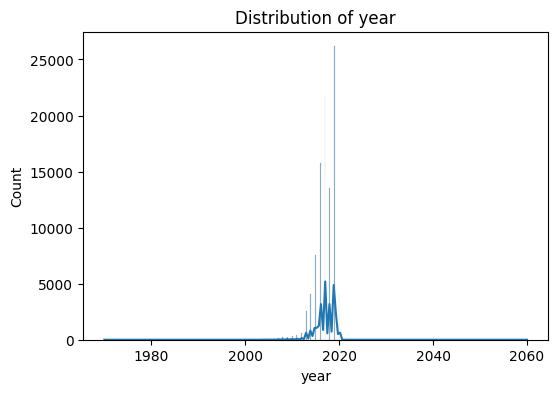

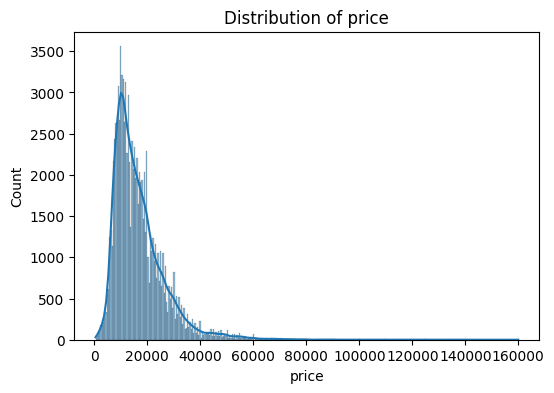

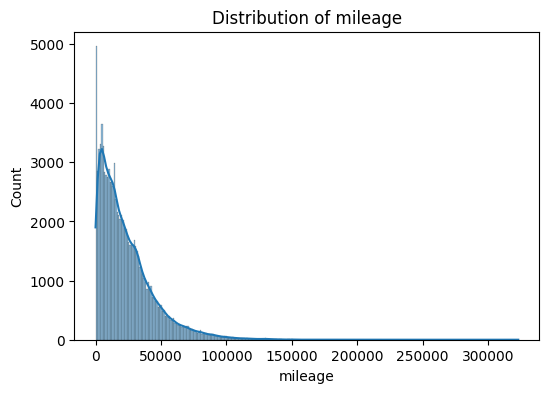

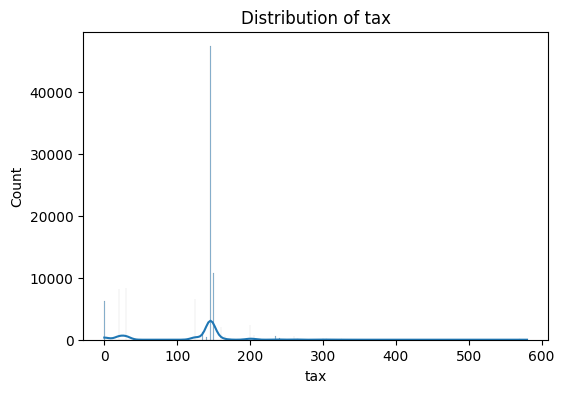

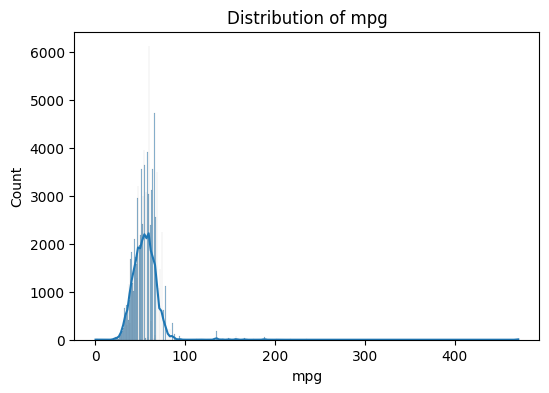

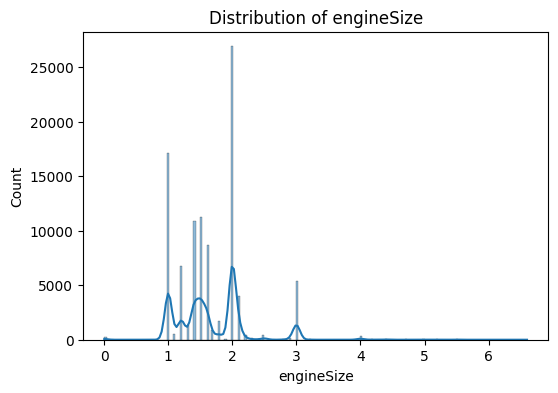

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

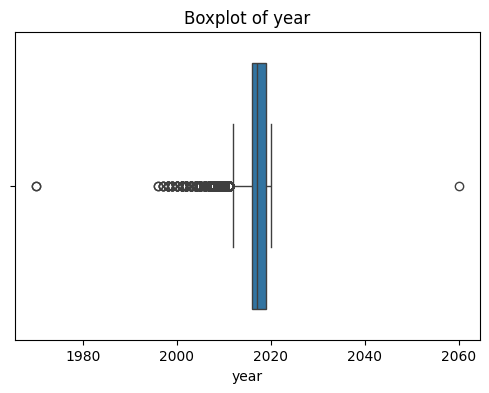

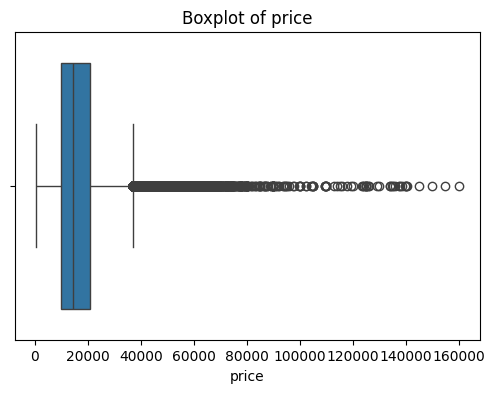

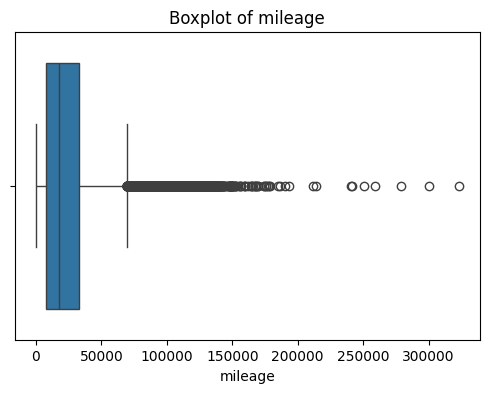

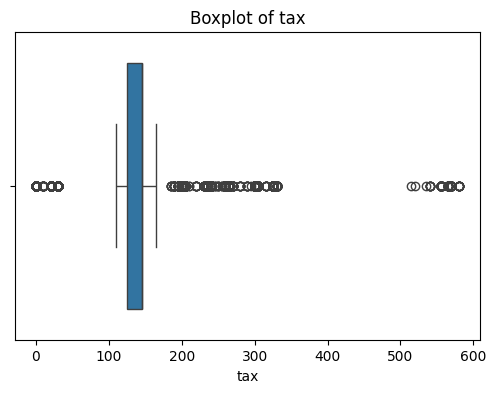

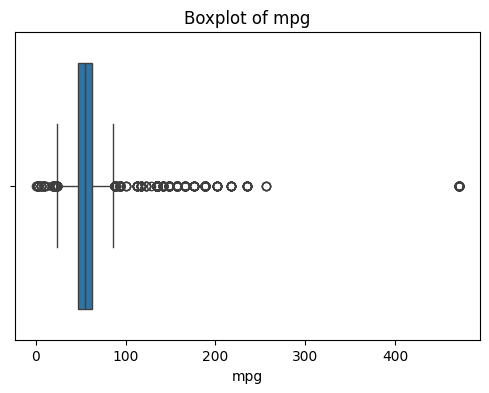

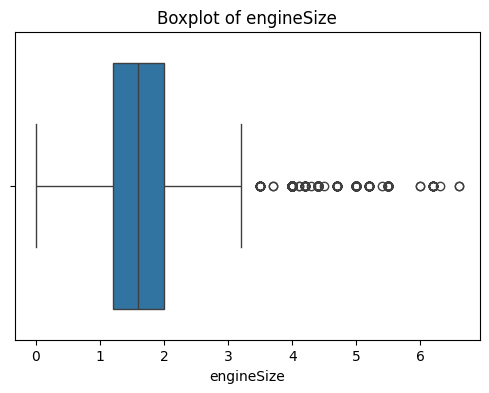

In [13]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# :- Categorical Features

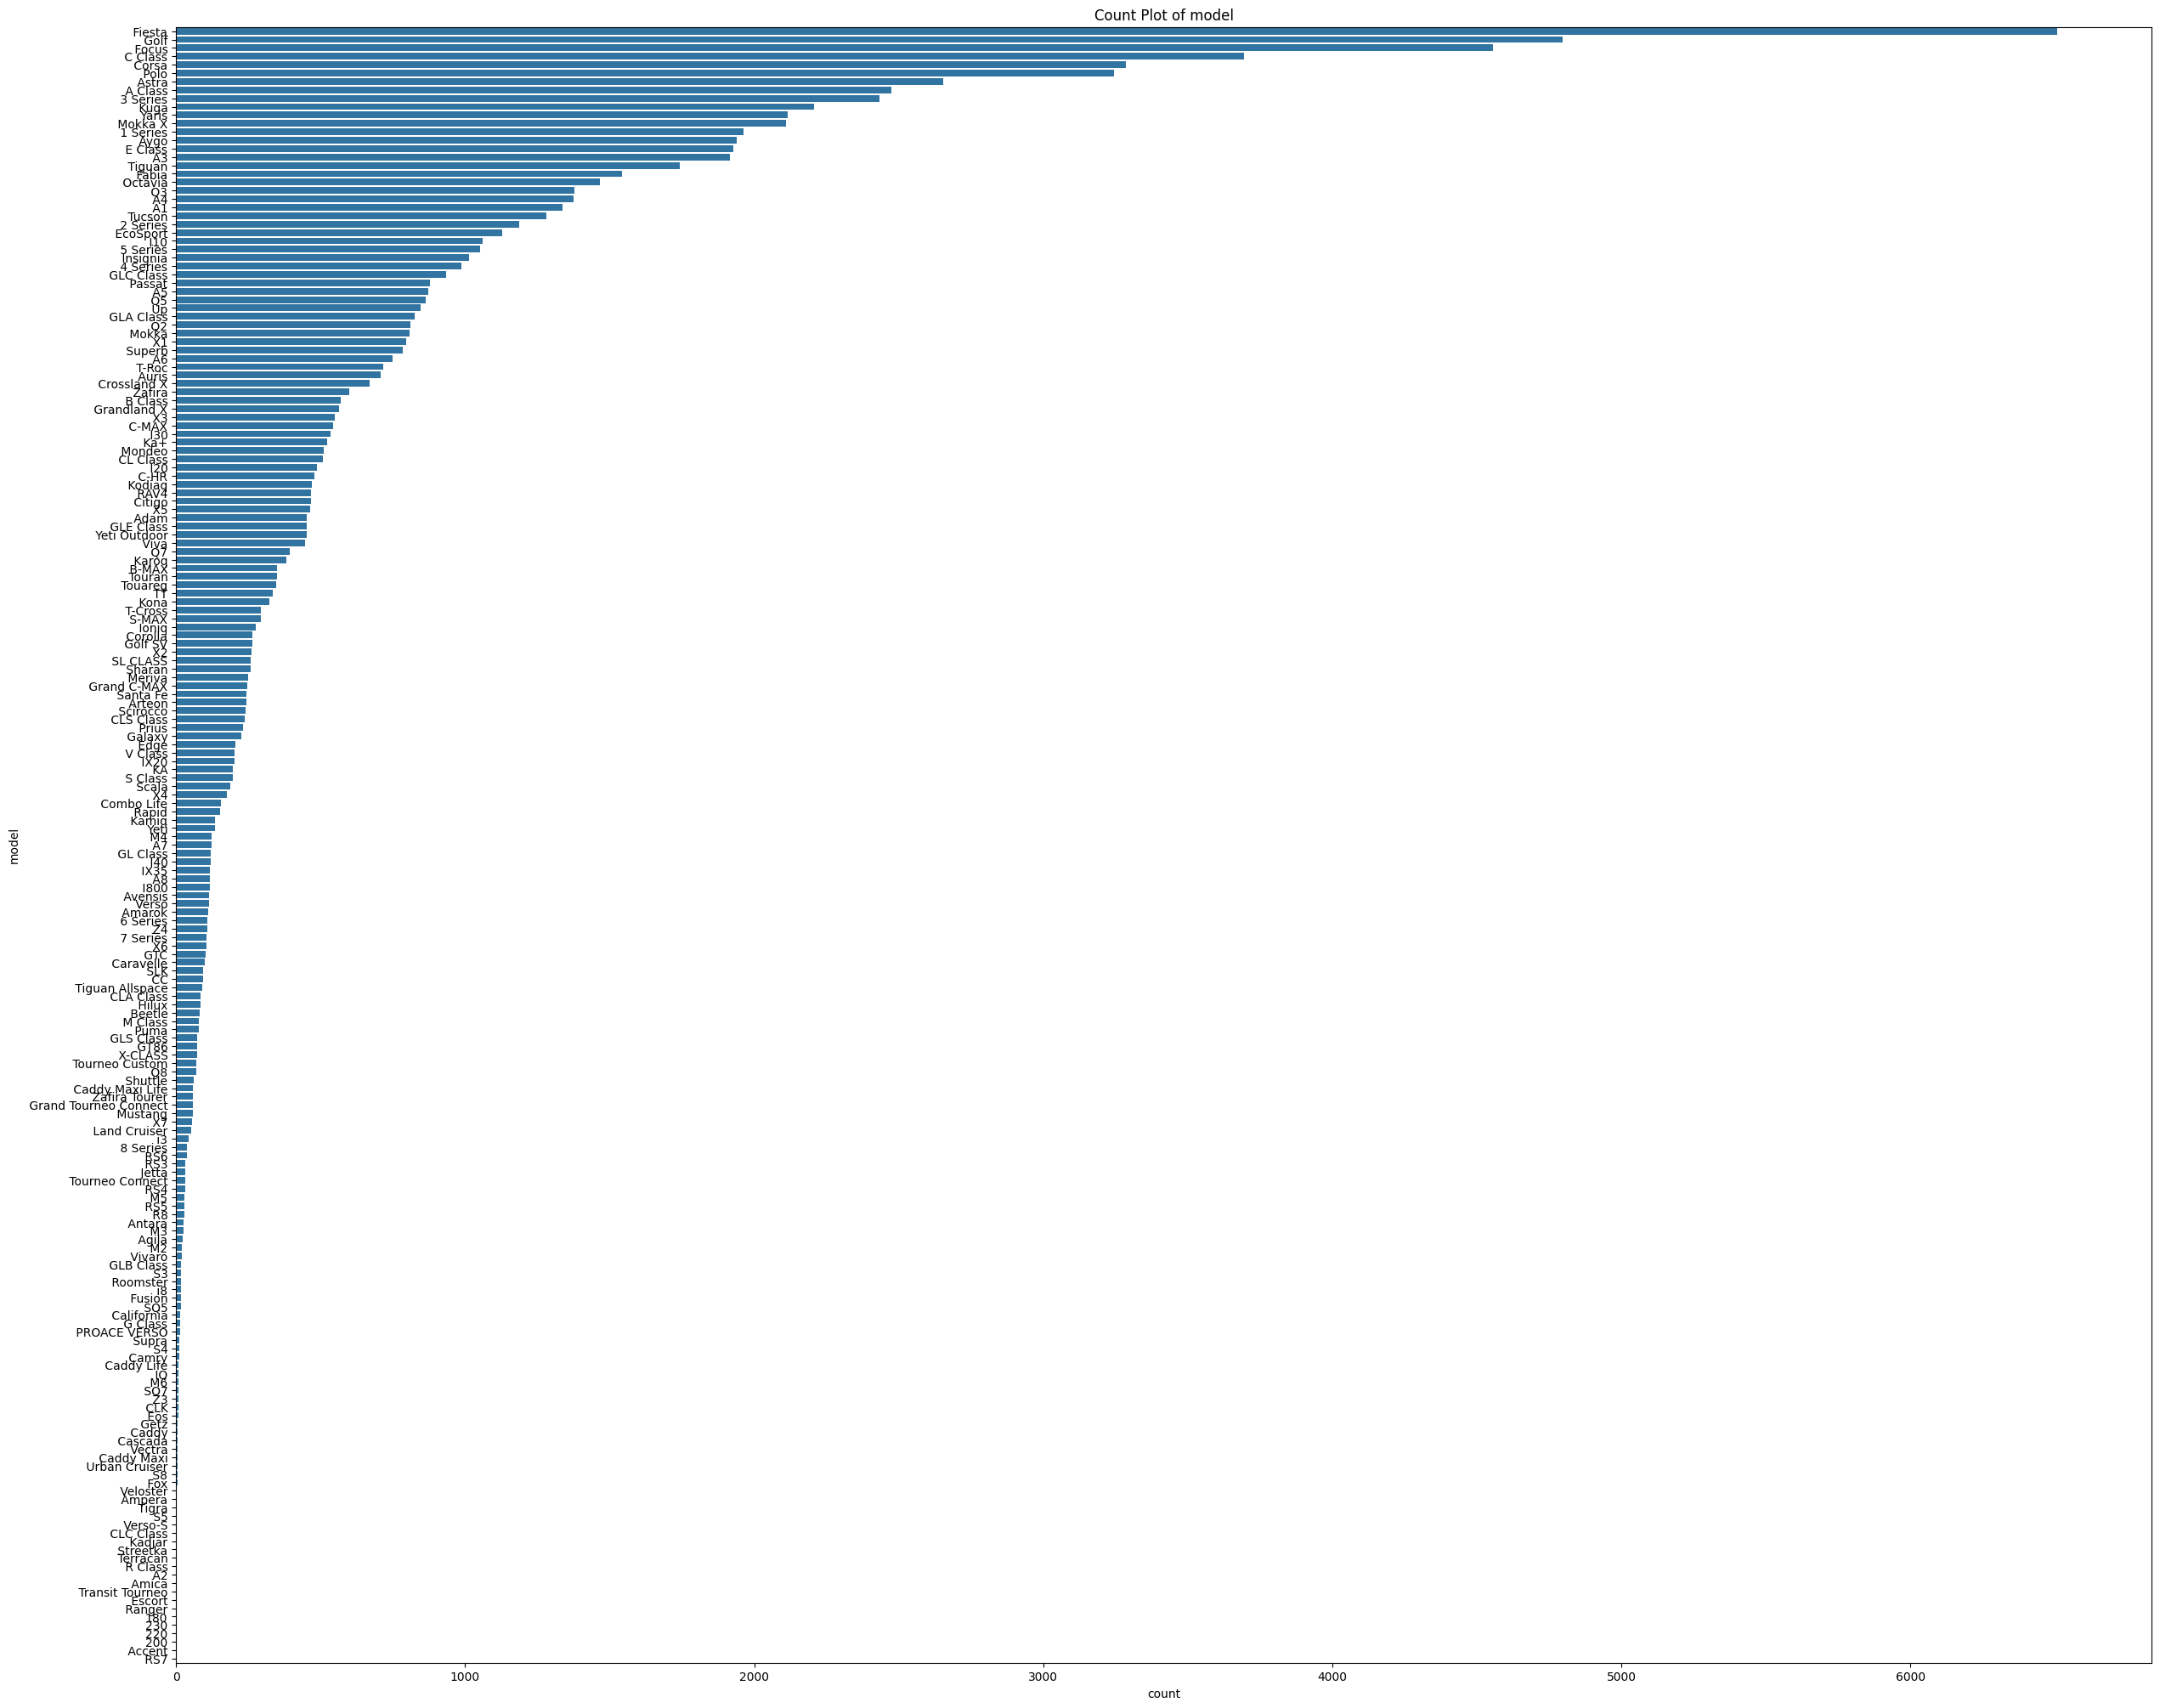

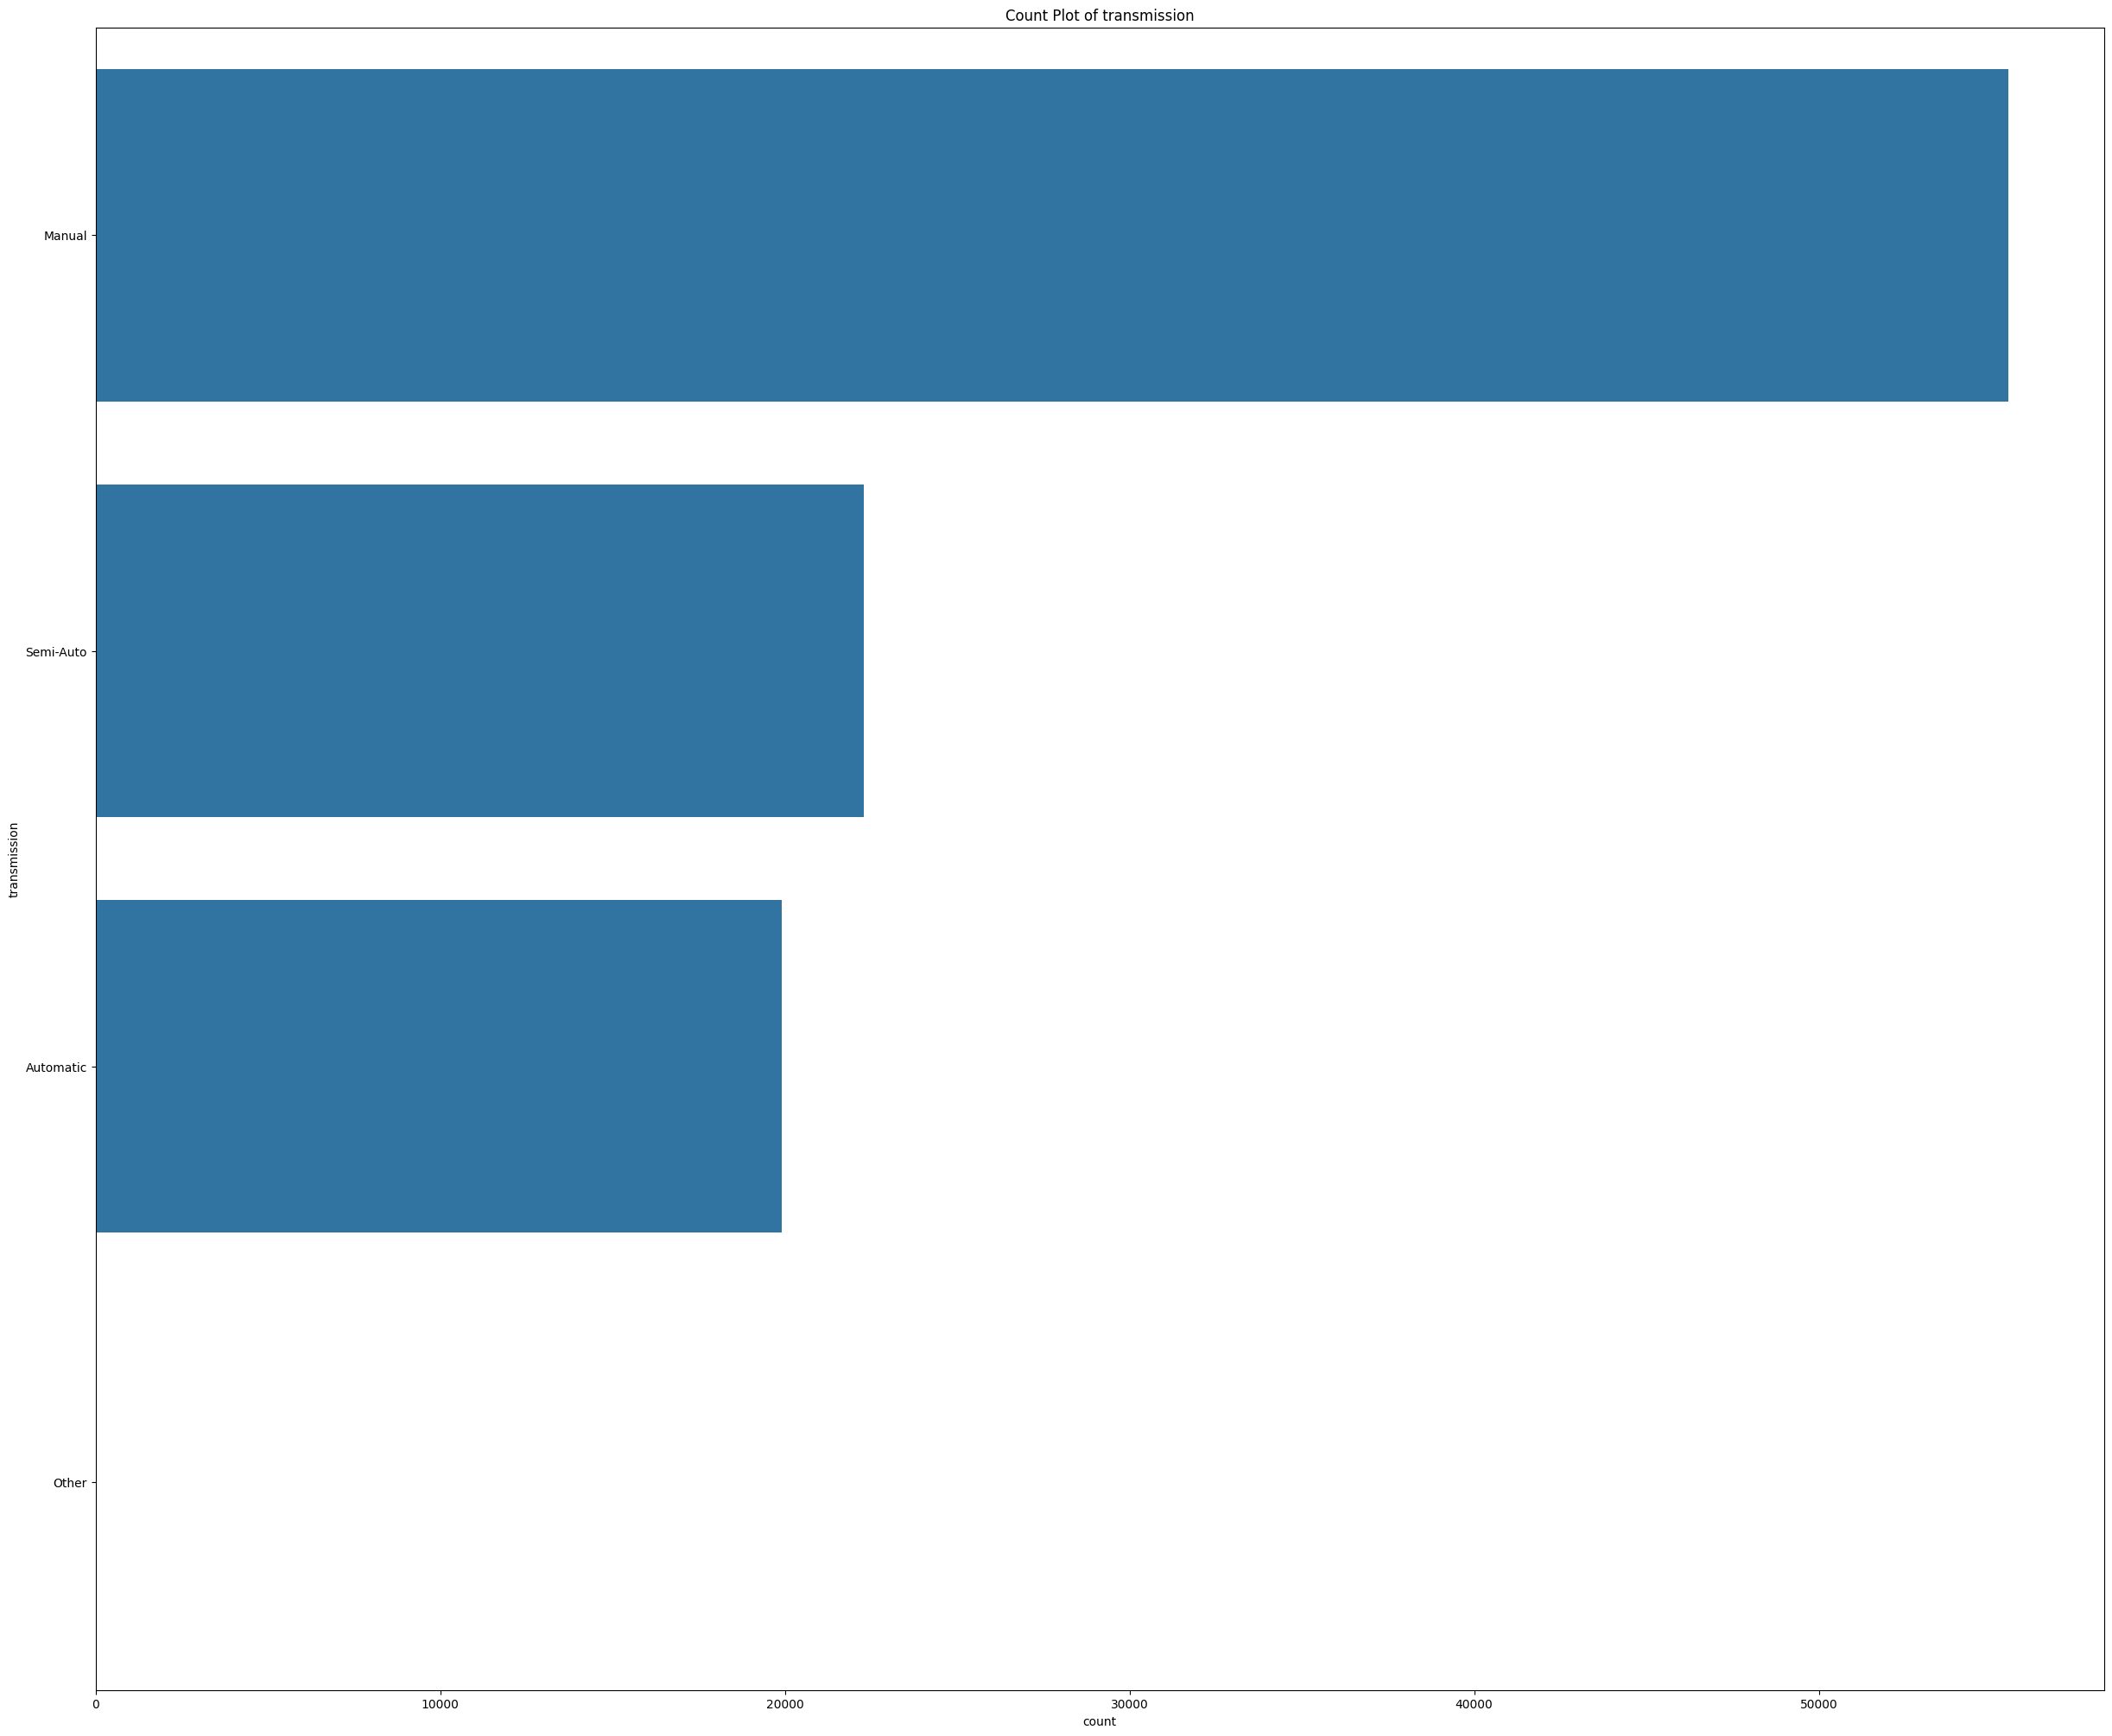

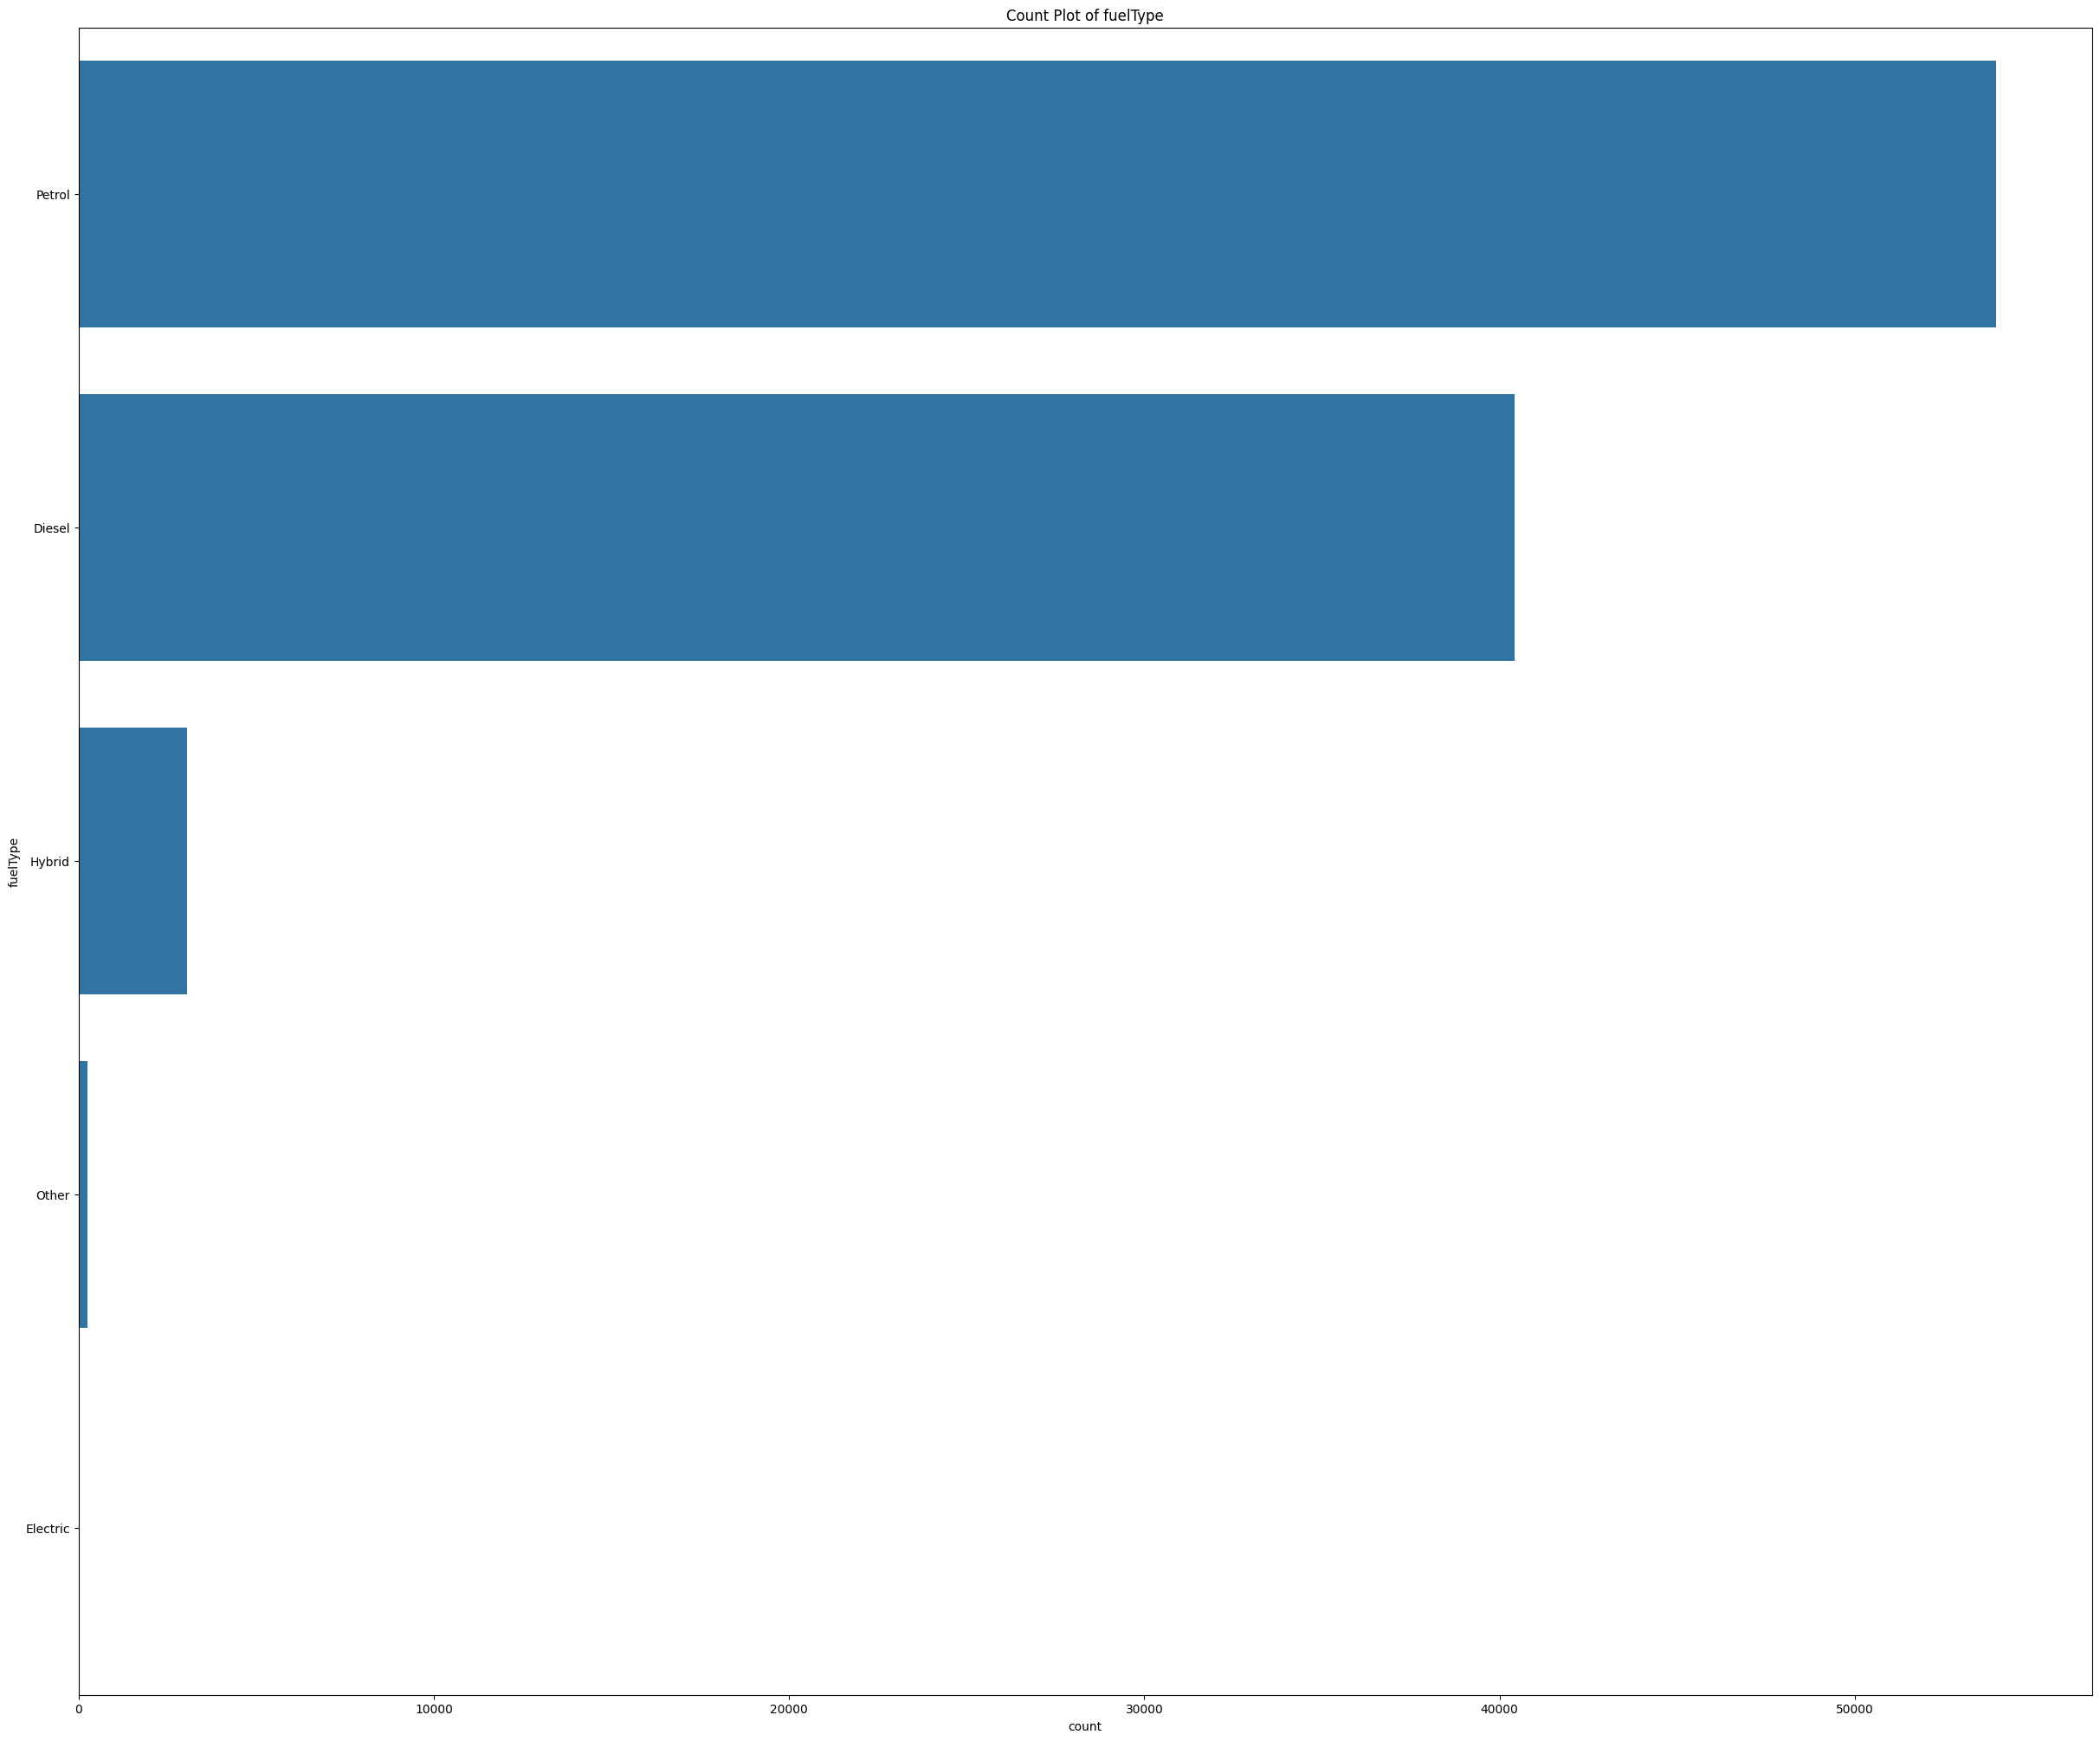

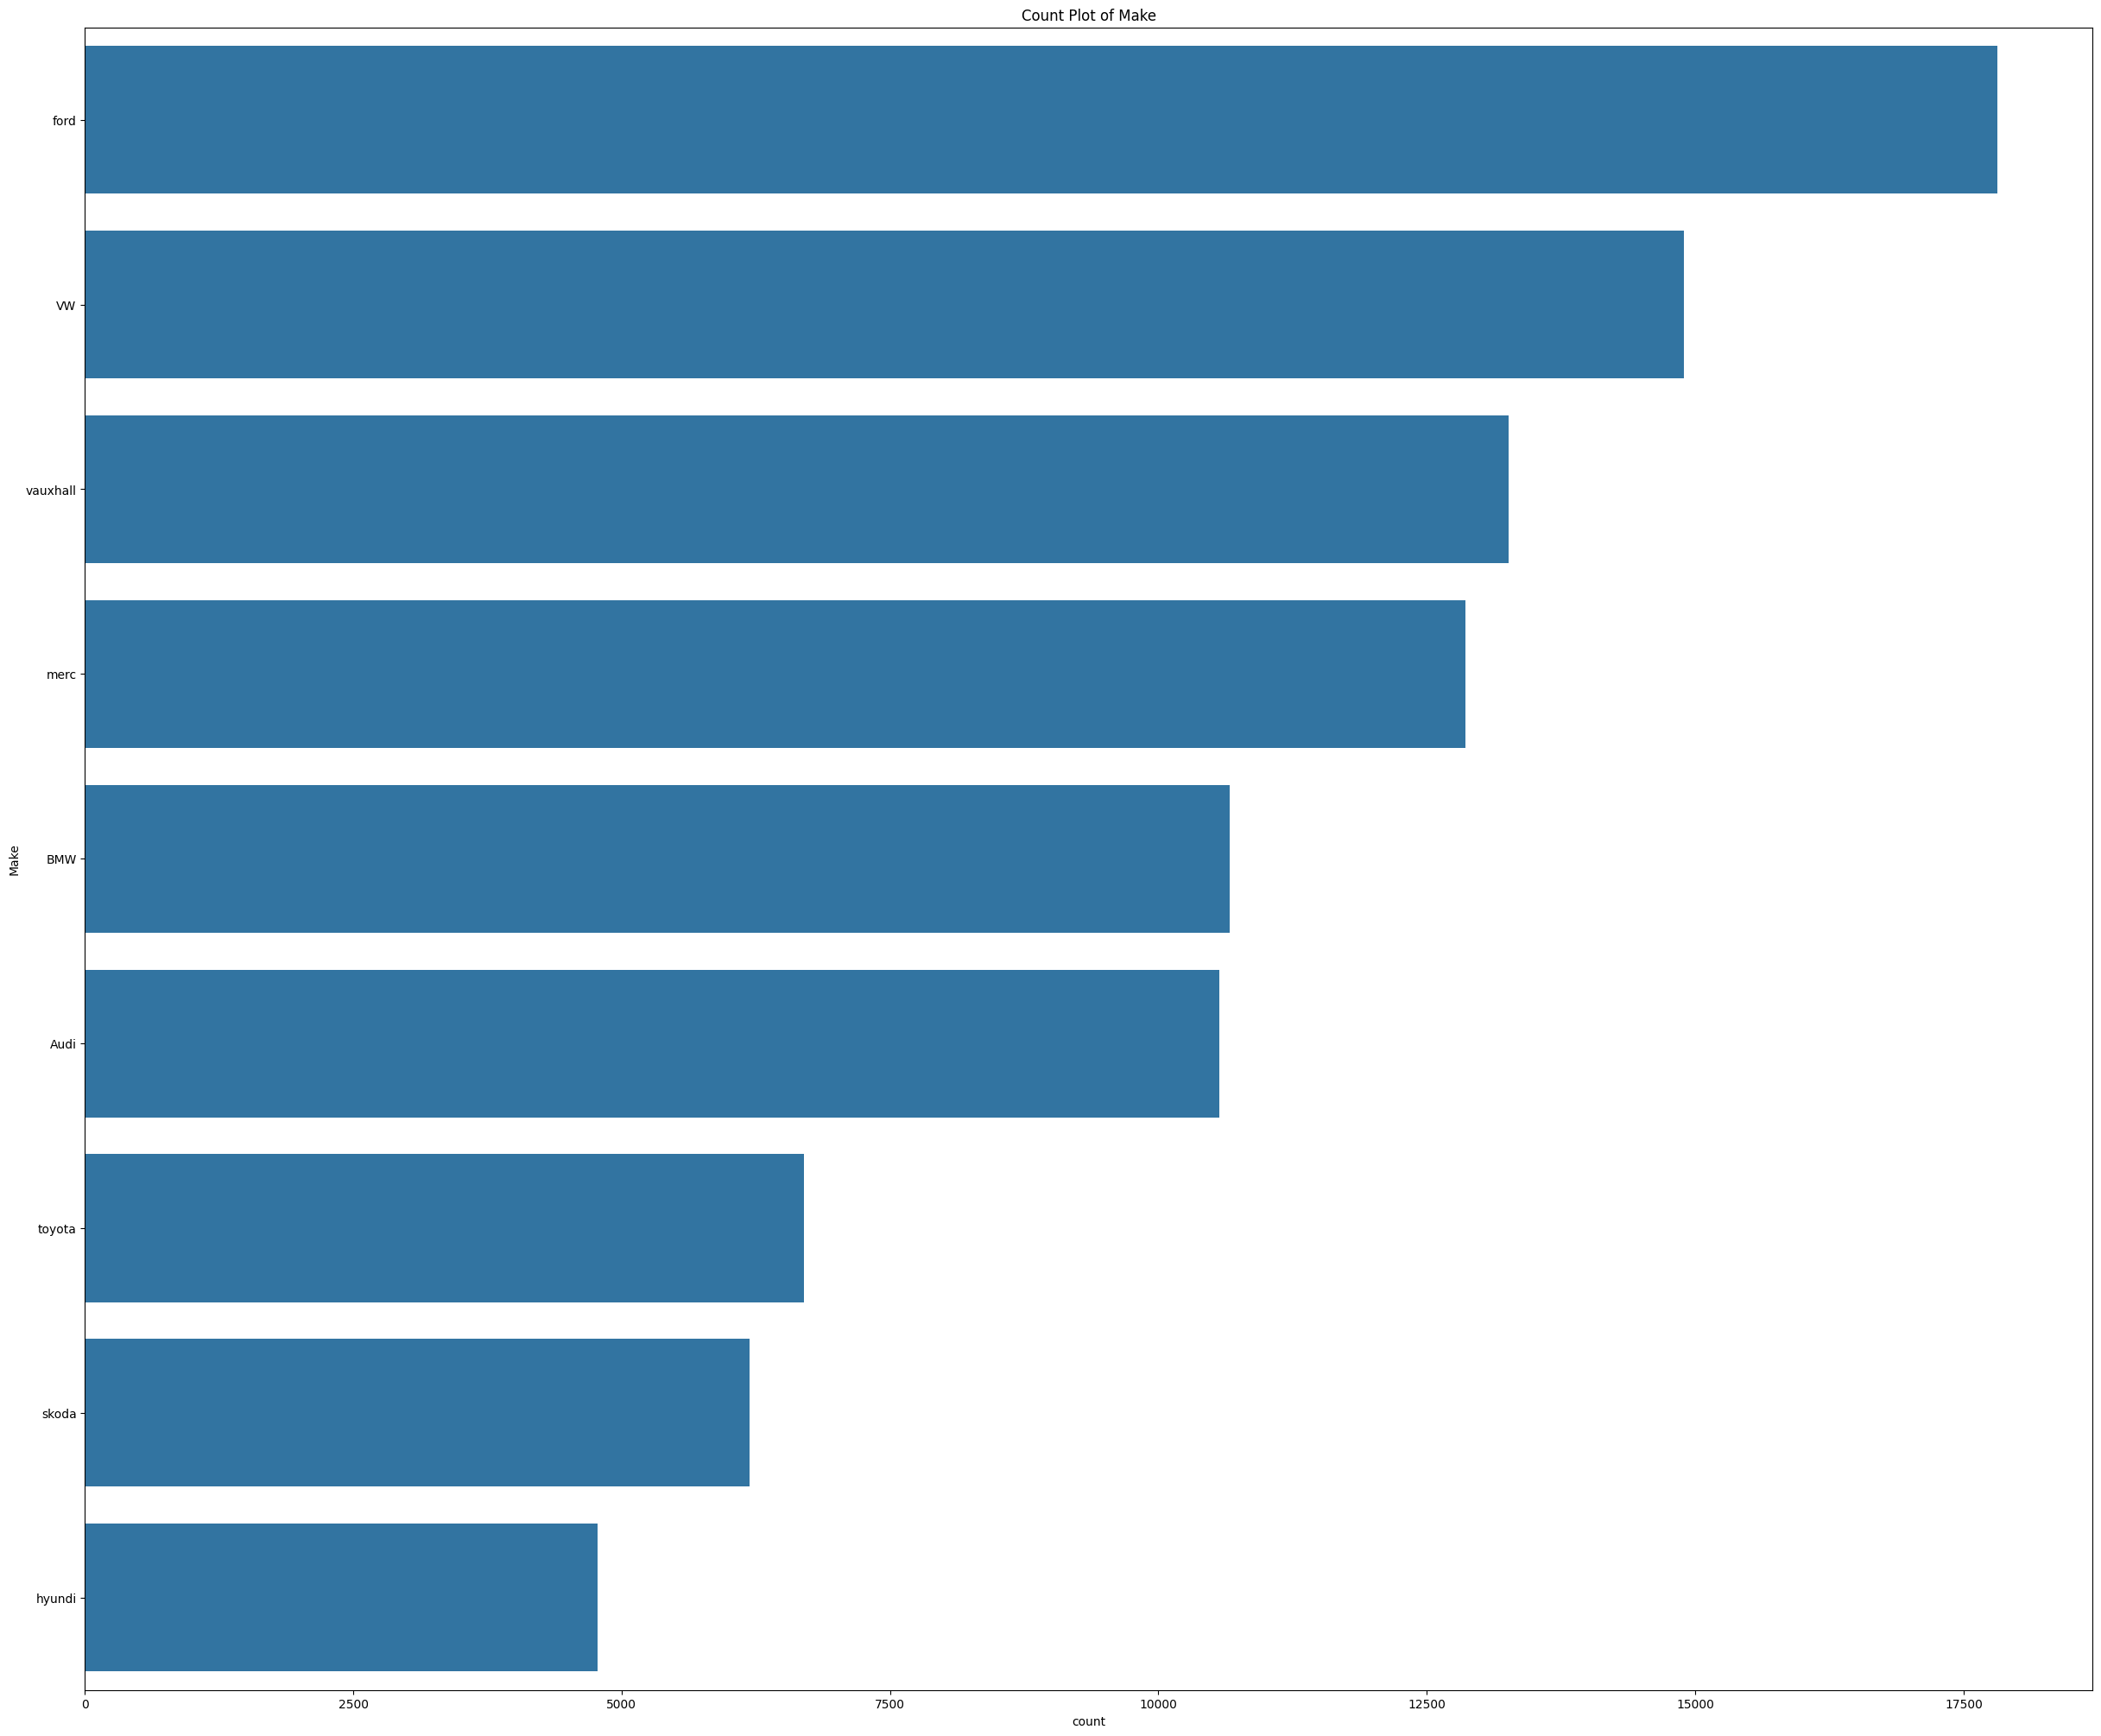

In [14]:
for col in categorical_columns:
    plt.figure(figsize=(30,25))
    sns.countplot(y=df[col],
                  order=df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.show()

# :- Bivariate Analysis

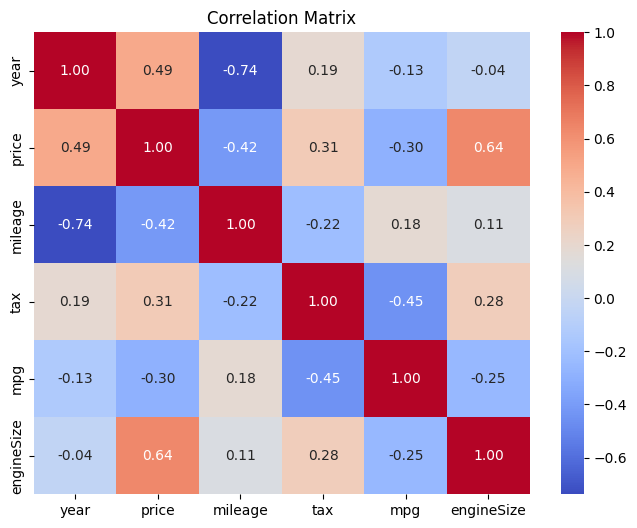

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(df[numerical_columns].corr(),      # Correlation Matrix
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

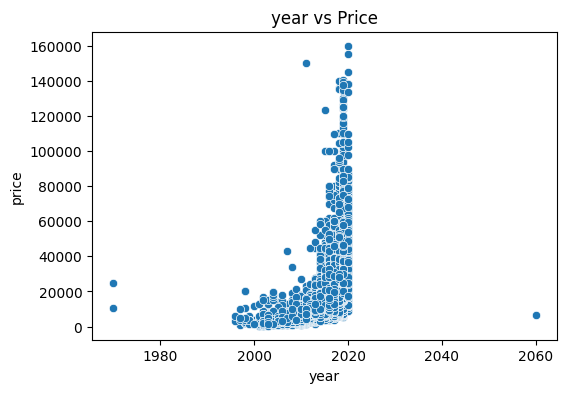

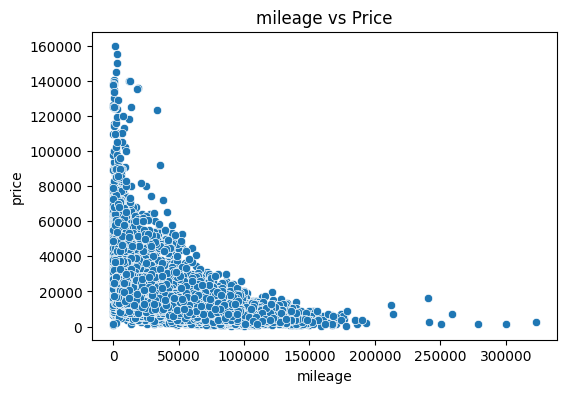

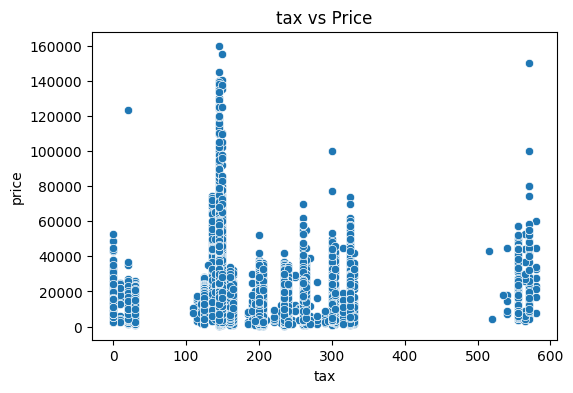

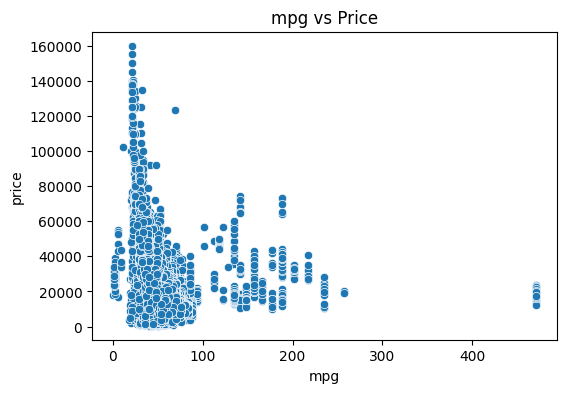

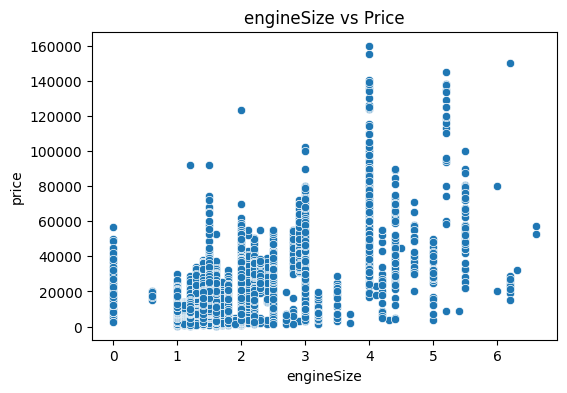

In [16]:
features = ['year','mileage','tax','mpg','engineSize']

for feature in features:
    plt.figure(figsize=(6,4))                                 # Price vs Numerical Features
    sns.scatterplot(x=df[feature], y=df['price'])
    plt.title(f"{feature} vs Price")
    plt.show()

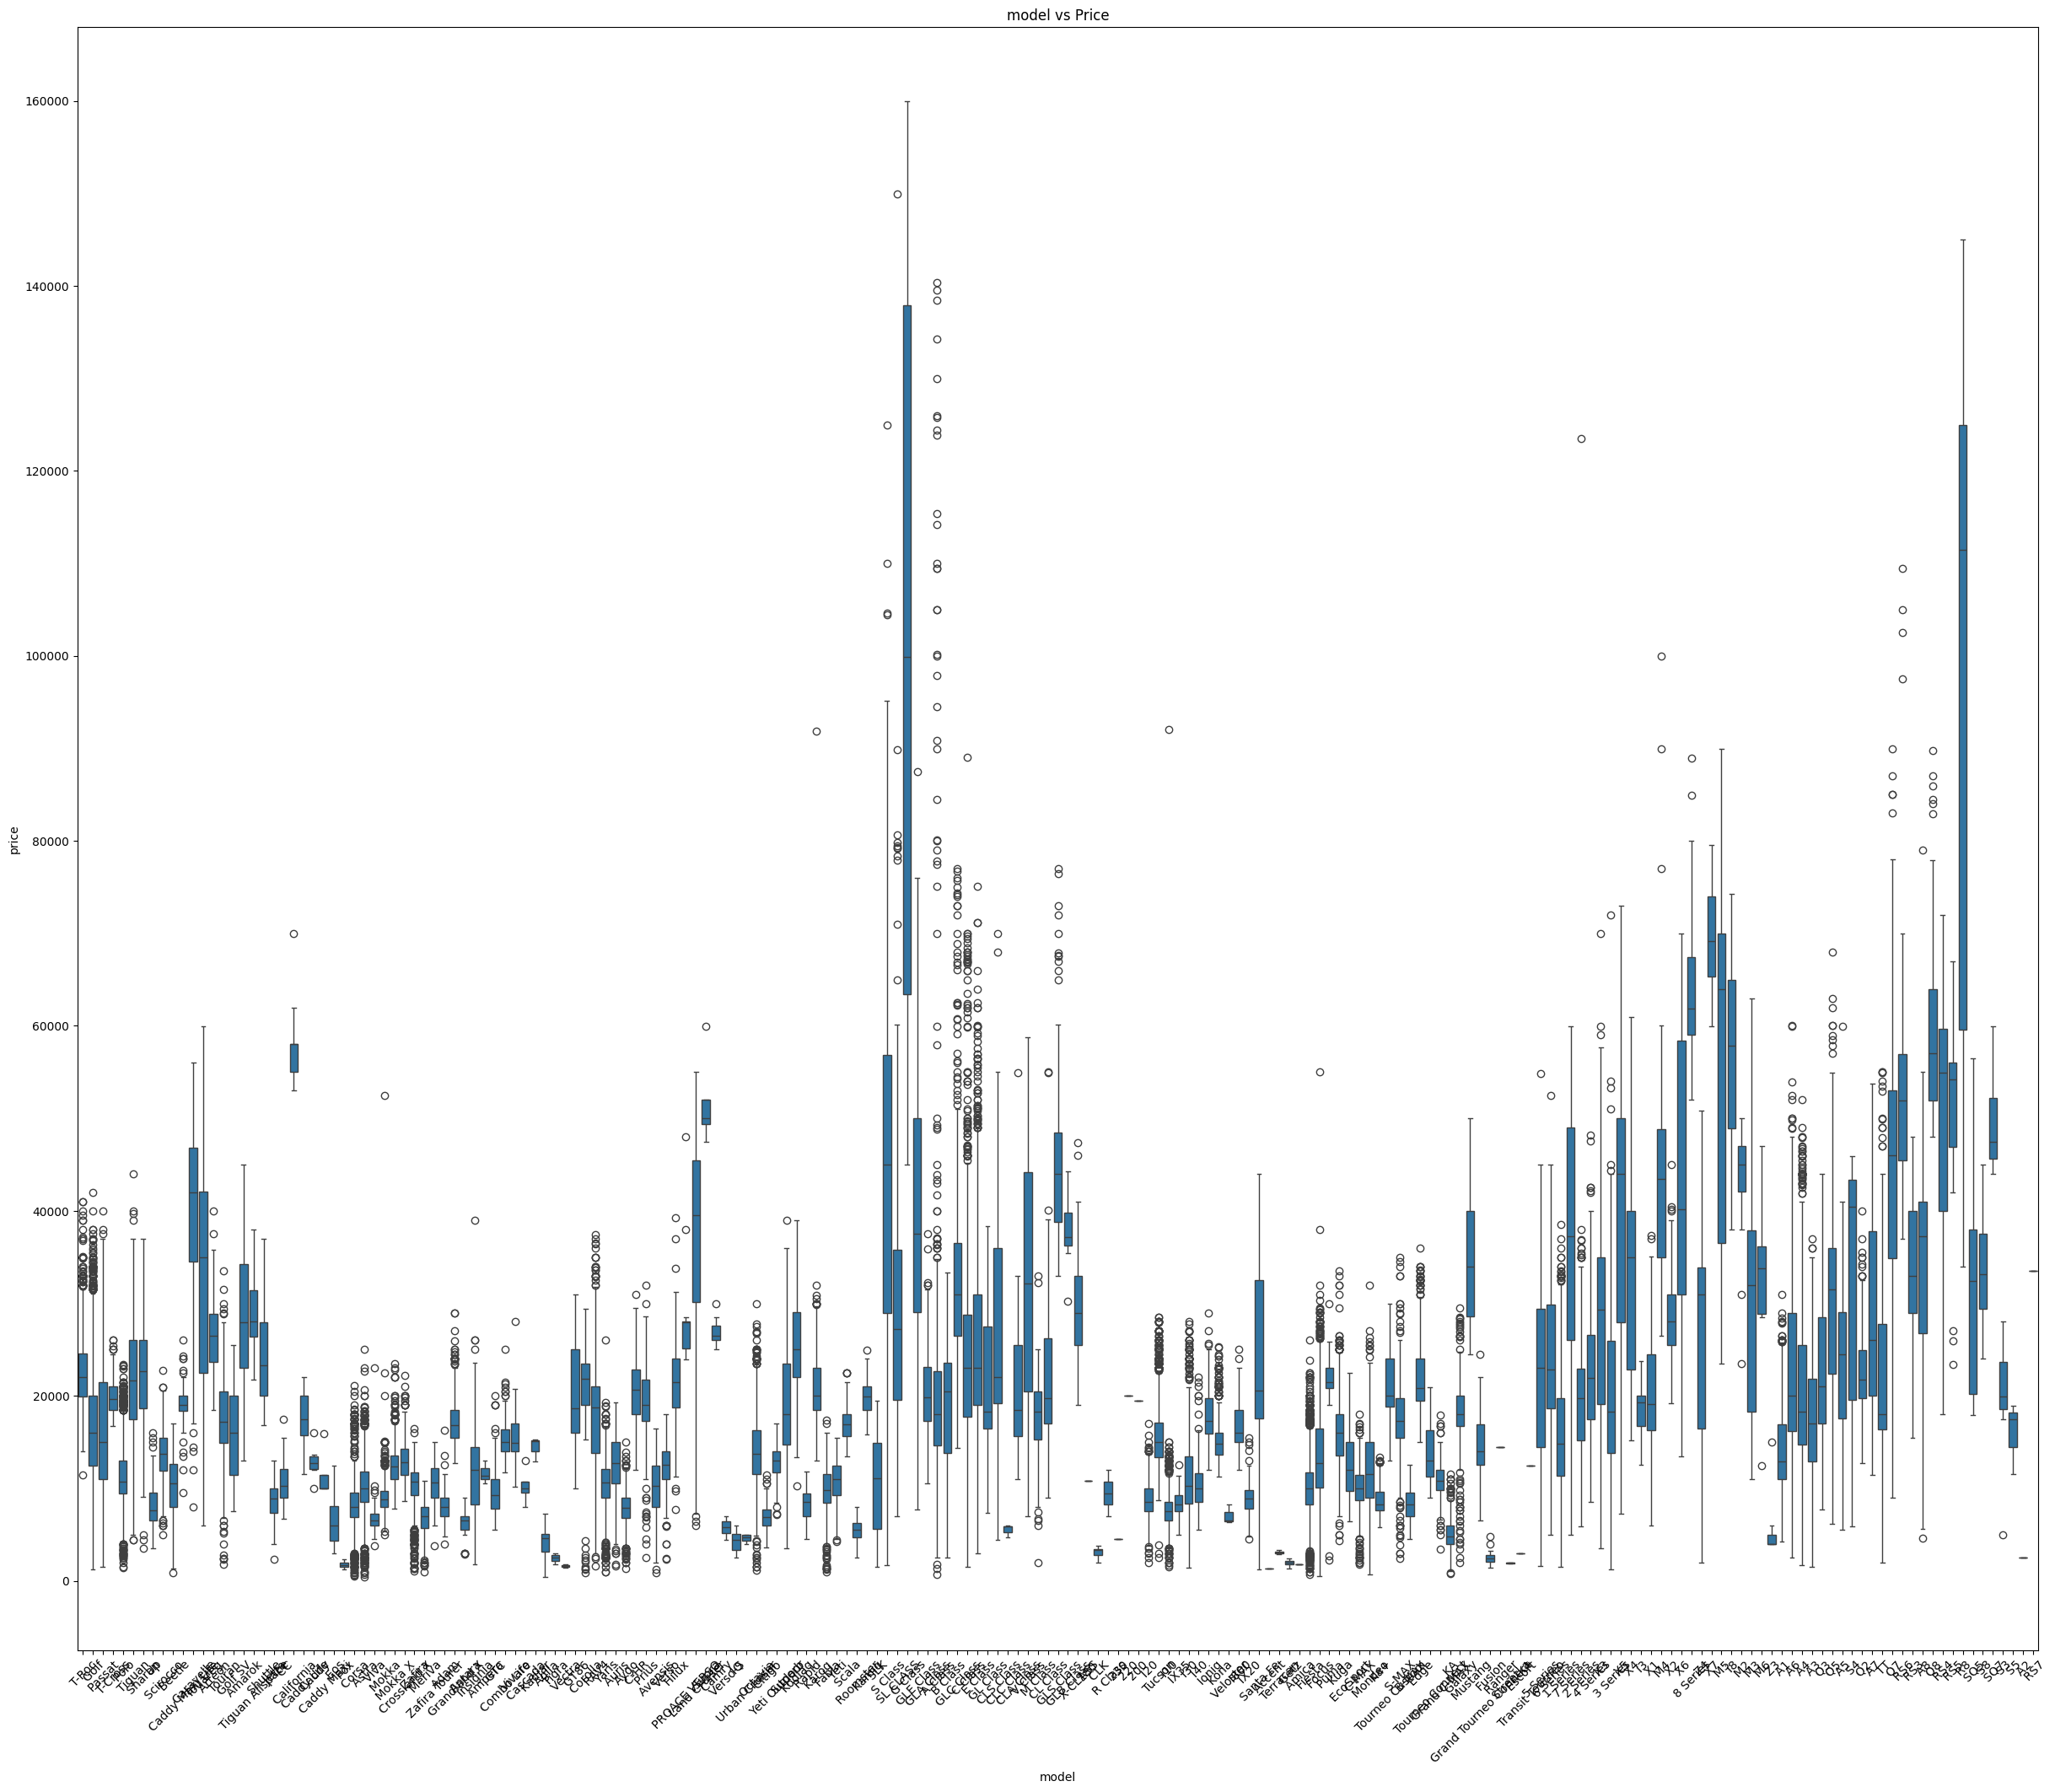

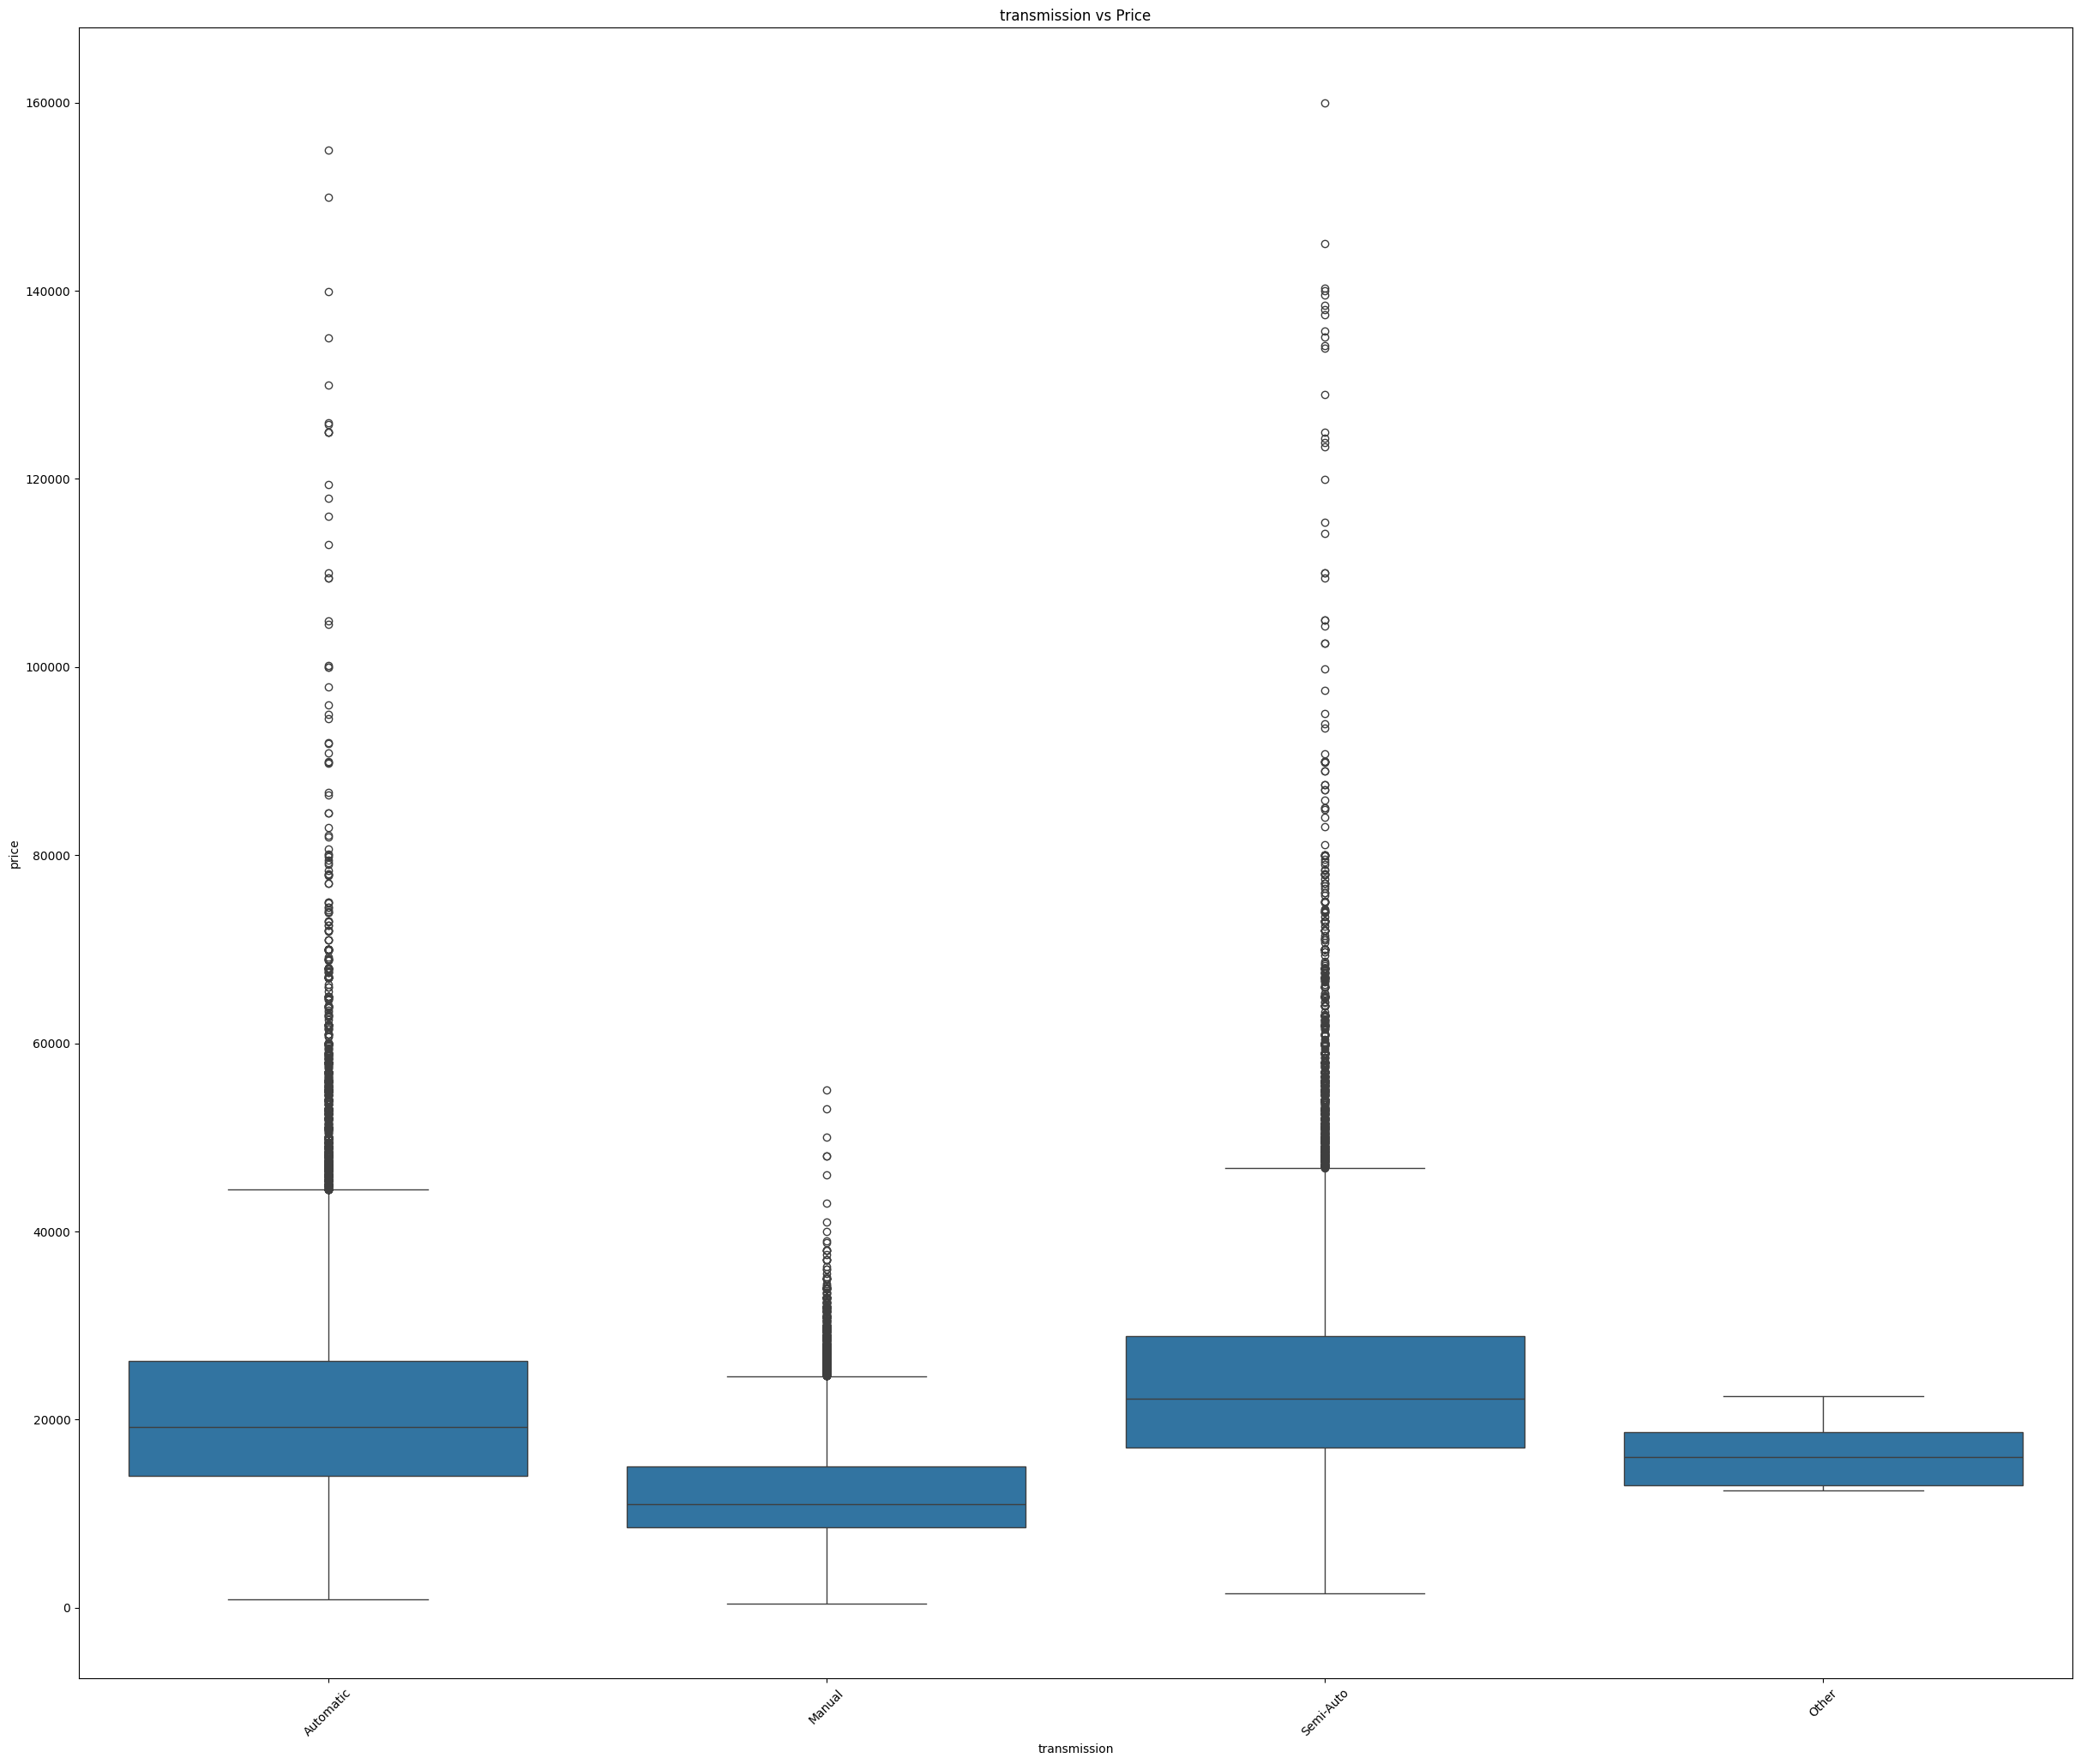

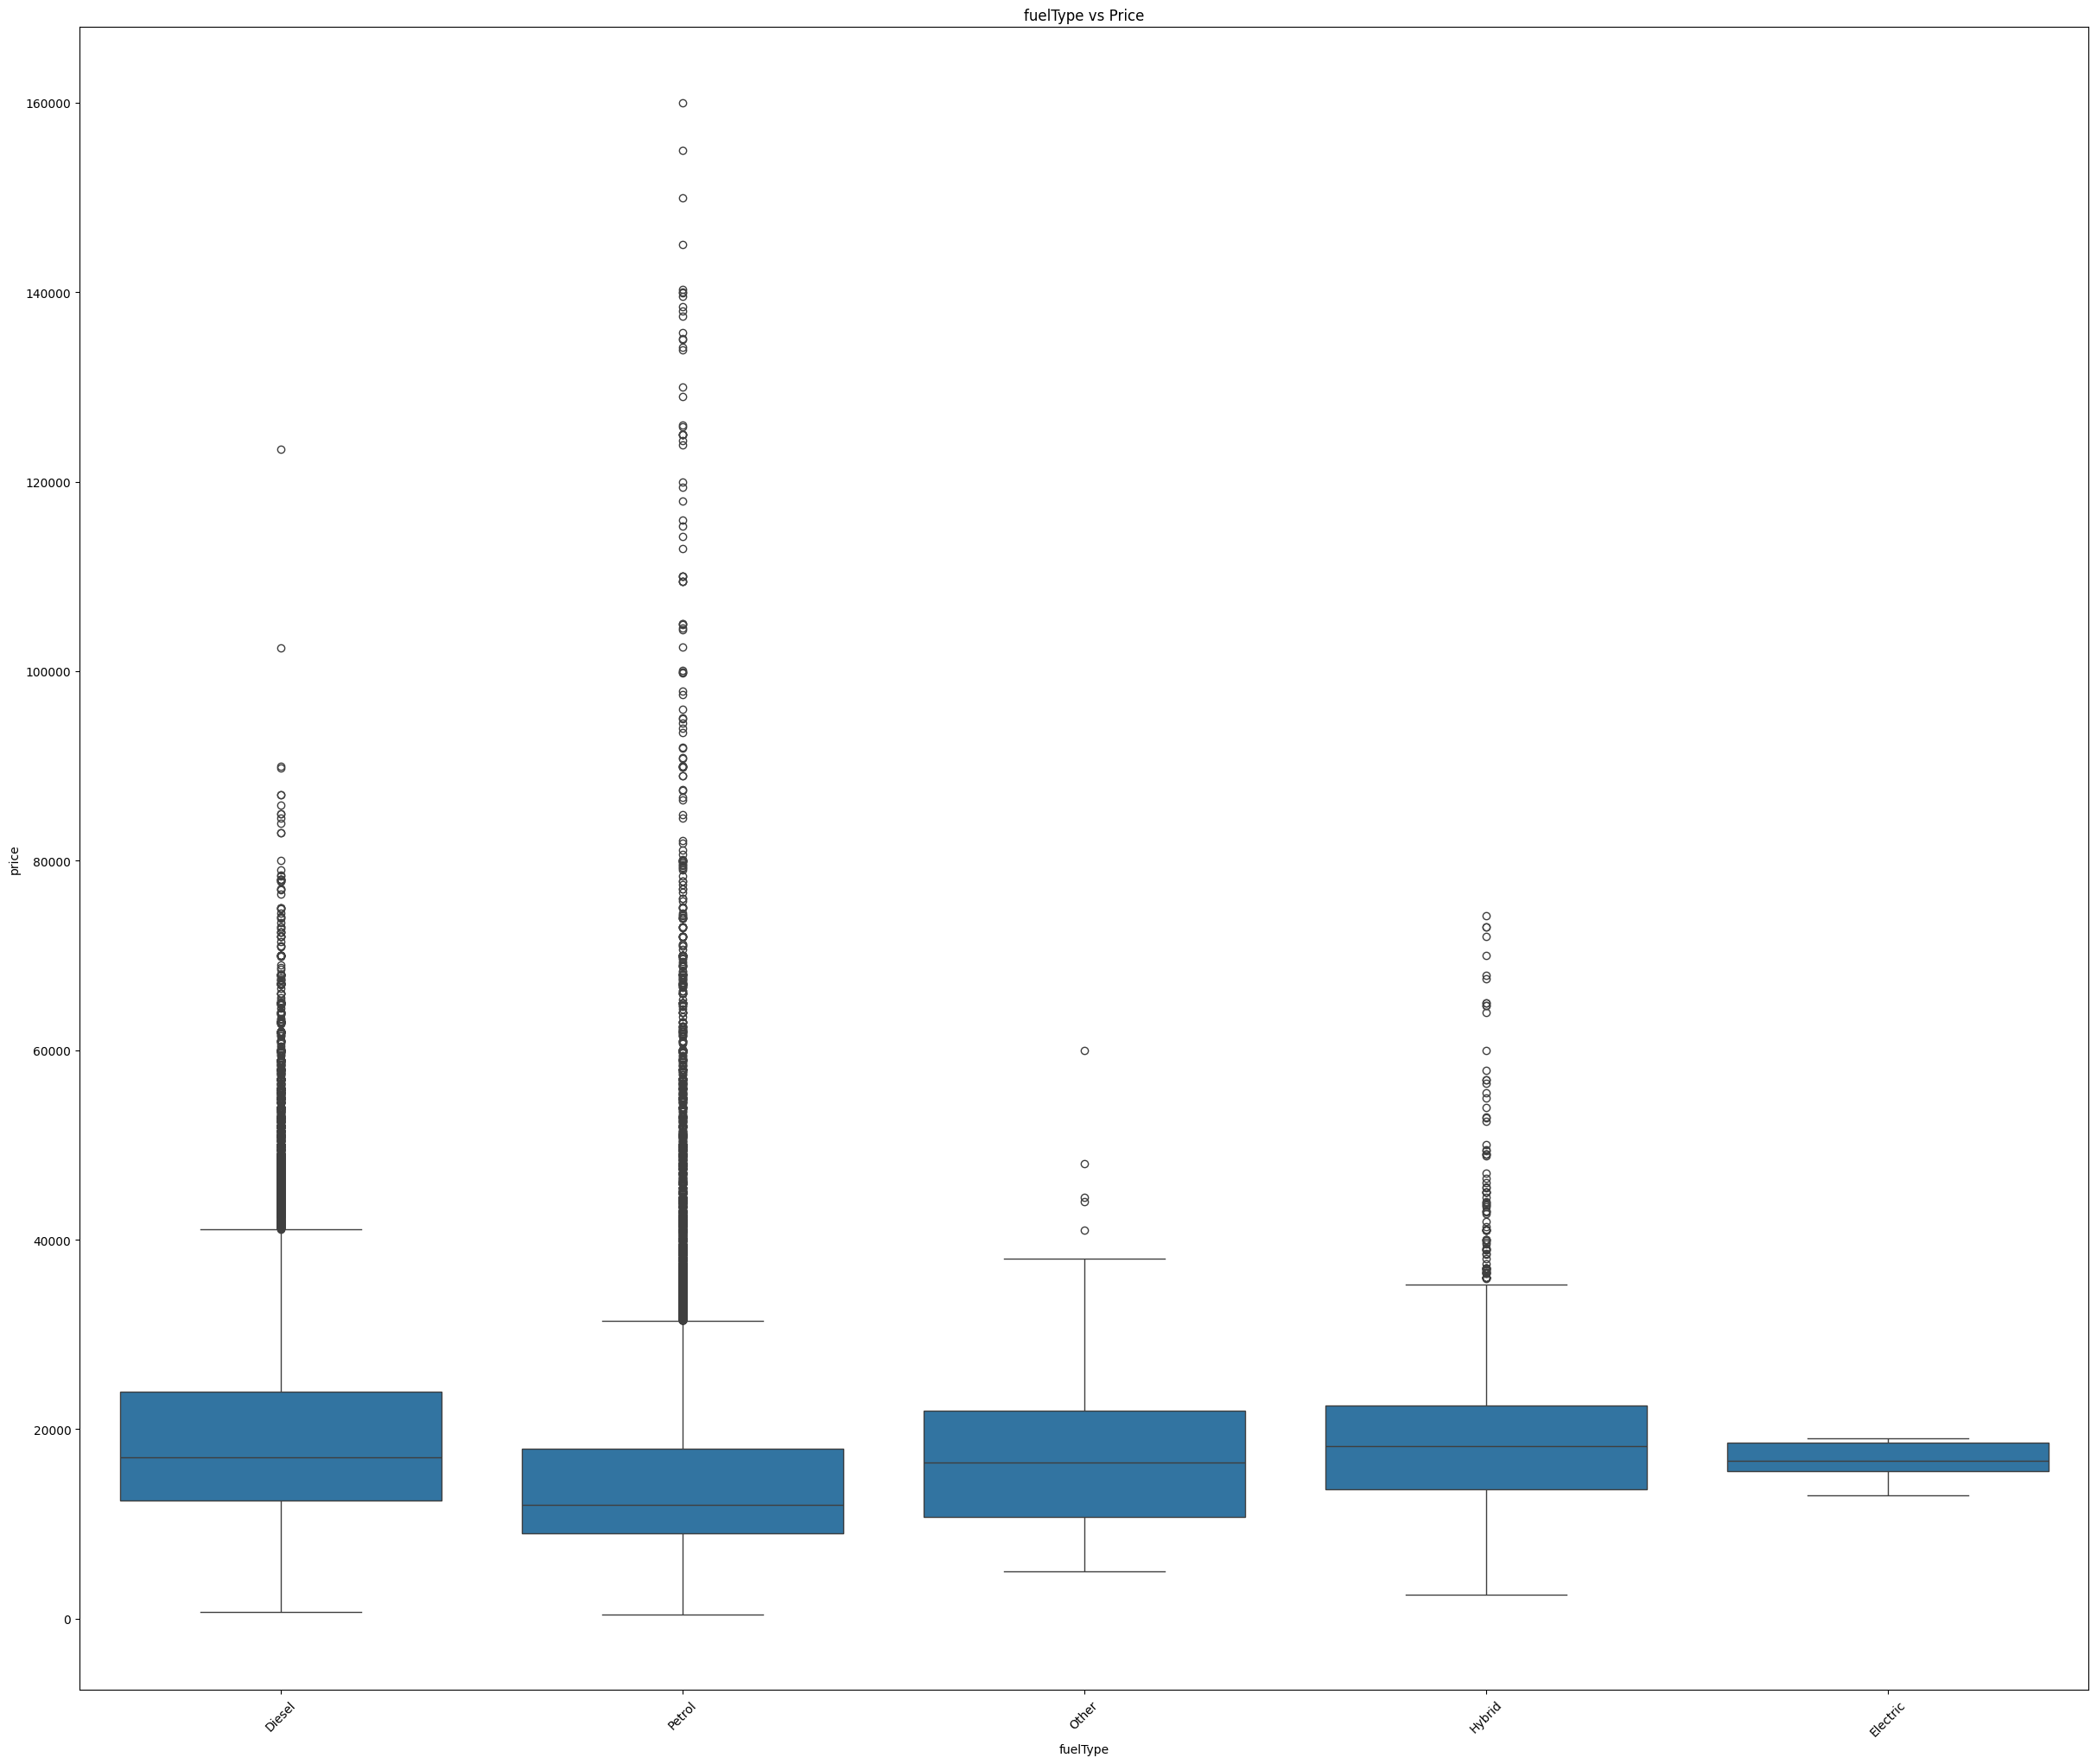

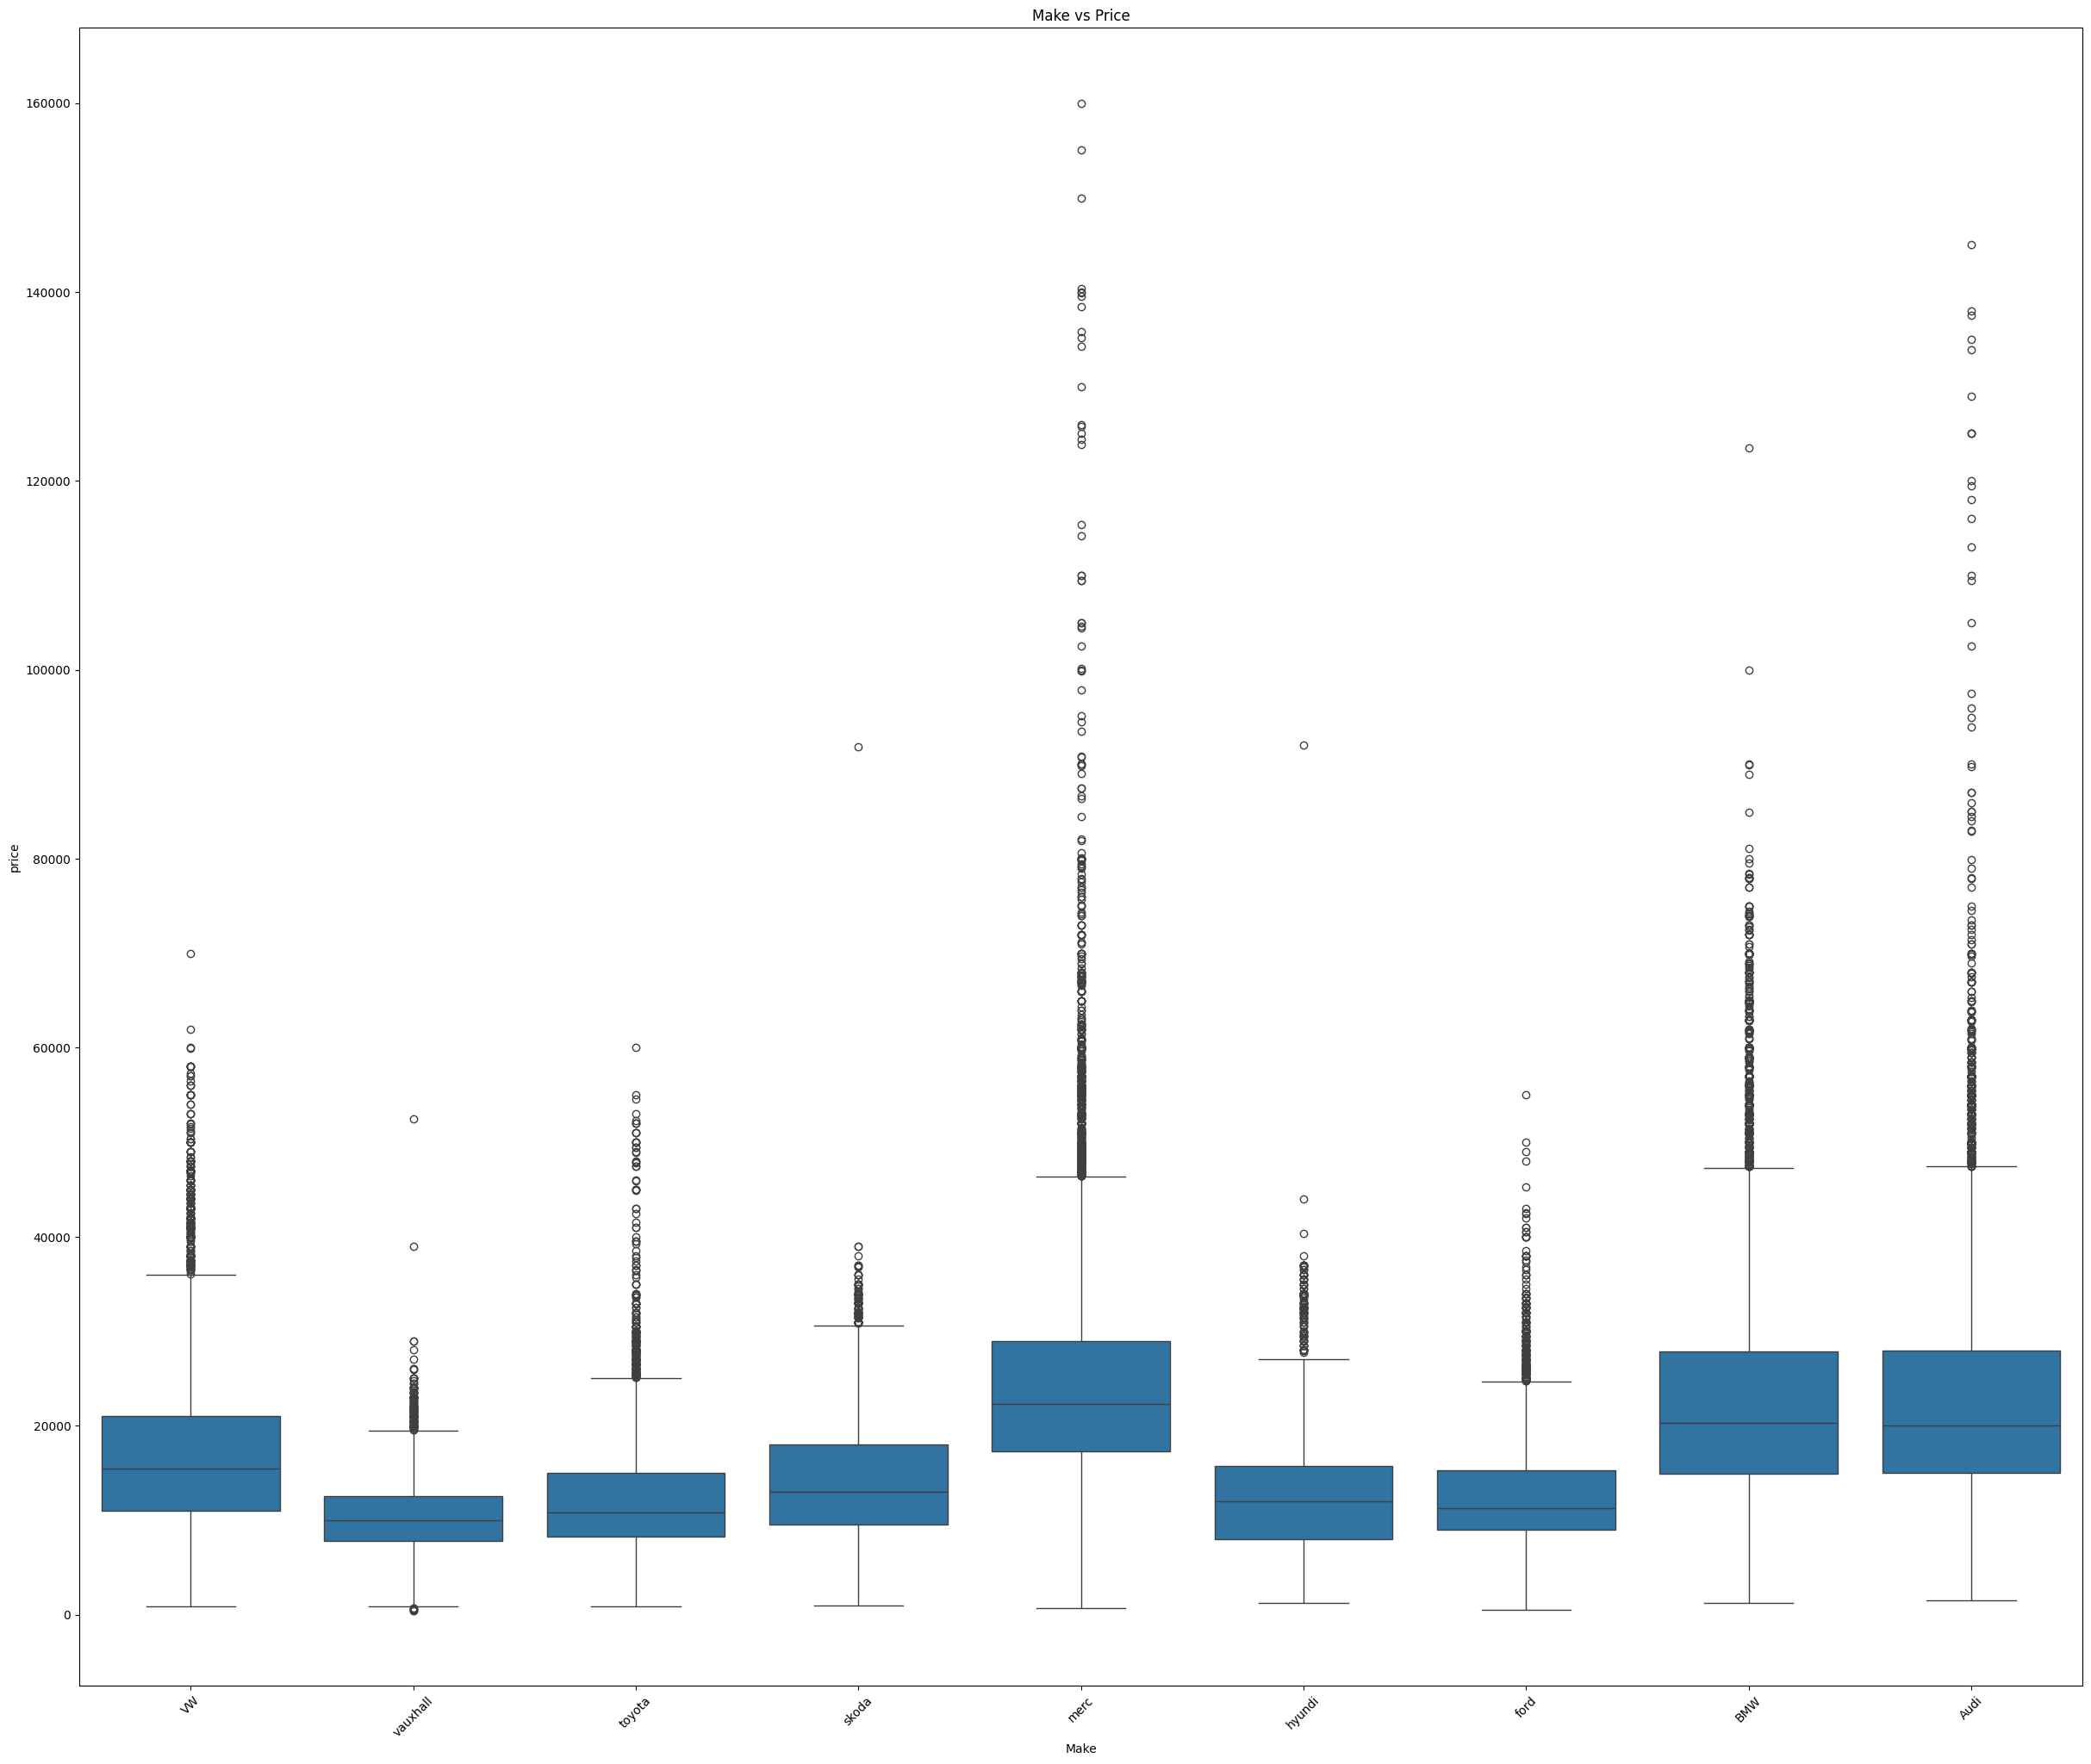

In [17]:
for col in categorical_columns:
    plt.figure(figsize=(30,25))
    sns.boxplot(x=df[col], y=df['price'])              # Price vs Categorical Features
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Price")
    plt.show()

# :- Skewness

In [18]:
df[numerical_columns].skew().sort_values(ascending=False)

mpg           8.973054
price         2.363848
mileage       1.779626
engineSize    1.312176
tax           0.036054
year         -1.911889
dtype: float64

In [19]:
columns_to_transform = ['mileage', 'engineSize']

for col in columns_to_transform:
    df[col] = np.log1p(df[col])

# :- Outlier Detection

In [20]:
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[numerical_columns] < (Q1 - 1.5 * IQR)) |
            (df[numerical_columns] > (Q3 + 1.5 * IQR)))

outliers.sum().sort_values(ascending=False)

tax           28594
mileage        3995
price          3825
year           1735
mpg             930
engineSize      894
dtype: int64

# Label Encoder Categorical Features

In [21]:
from sklearn.preprocessing import LabelEncoder

# Store encoders for future use
label_encoders = {}

categorical_cols = ['model', 'transmission', 'fuelType', 'Make']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Hyperparameter Tunning

# :- Imports

In [24]:
import optuna

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import cross_val_score

# :- Modles

In [25]:
def objective(trial):

    model_name = trial.suggest_categorical(
        "model",
        ["XGBoost", "CatBoost"]
    )

    if model_name == "XGBoost":

        model = XGBRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 400),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2),
            subsample=trial.suggest_float("subsample", 0.7, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
            min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
            gamma=trial.suggest_float("gamma", 0.0, 5.0),
            reg_alpha=trial.suggest_float("reg_alpha", 0.0, 5.0),
            reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0),
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

    else:

        model = CatBoostRegressor(
            iterations=trial.suggest_int("iterations", 100, 400),
            depth=trial.suggest_int("depth", 4, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            random_strength=trial.suggest_float("random_strength", 0.0, 5.0),
            bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 5.0),
            verbose=0,
            random_state=42
        )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    ).mean()

    return score

In [29]:


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=10,show_progress_bar=True)


[I 2026-06-28 10:10:58,723] A new study created in memory with name: no-name-9d6d2dc2-284c-40b0-b063-67290484d961


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-06-28 10:11:37,875] Trial 0 finished with value: 0.8792800637928195 and parameters: {'model': 'CatBoost', 'iterations': 191, 'depth': 9, 'learning_rate': 0.014285840201978078, 'l2_leaf_reg': 6.109941664593445, 'random_strength': 2.590486179786158, 'bagging_temperature': 1.6232366906804507}. Best is trial 0 with value: 0.8792800637928195.
[I 2026-06-28 10:12:03,504] Trial 1 finished with value: 0.9539459109306335 and parameters: {'model': 'XGBoost', 'n_estimators': 266, 'max_depth': 6, 'learning_rate': 0.06409932148219667, 'subsample': 0.7609722167047542, 'colsample_bytree': 0.9317555196985403, 'min_child_weight': 10, 'gamma': 0.07073631743563402, 'reg_alpha': 4.352011482357035, 'reg_lambda': 1.5854691571781143}. Best is trial 1 with value: 0.9539459109306335.
[I 2026-06-28 10:12:34,388] Trial 2 finished with value: 0.9518318665702831 and parameters: {'model': 'CatBoost', 'iterations': 399, 'depth': 5, 'learning_rate': 0.15327537752429604, 'l2_leaf_reg': 5.400073135694672, 'rand

In [30]:
print("Best Score:", study.best_value)
print("\nBest Parameters:")
print(study.best_params)

Best Score: 0.9647530317306519

Best Parameters:
{'model': 'XGBoost', 'n_estimators': 267, 'max_depth': 10, 'learning_rate': 0.04575584820967337, 'subsample': 0.7945897603668544, 'colsample_bytree': 0.9940540671759872, 'min_child_weight': 3, 'gamma': 3.3644485533319117, 'reg_alpha': 0.22703829220635352, 'reg_lambda': 0.765523486475615}


# :- Training the best Model

In [31]:
best_params = study.best_params.copy()

model_name = best_params.pop("model")


if model_name == "XGBoost":

    best_model = XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

else:

    best_model = CatBoostRegressor(
        **best_params,
        verbose=0,
        random_state=42
    )

best_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9940540671759872
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Model Evaluation

# :- Evaluation Metrics

In [32]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)


In [33]:
y_pred = best_model.predict(X_test)

In [34]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAPE     : {mape*100:.2f}%")

R² Score : 0.9657
MAE      : 1091.03
MSE      : 3311539.25
RMSE     : 1819.76
MAPE     : 7.00%


# :- Actual vs Predicted

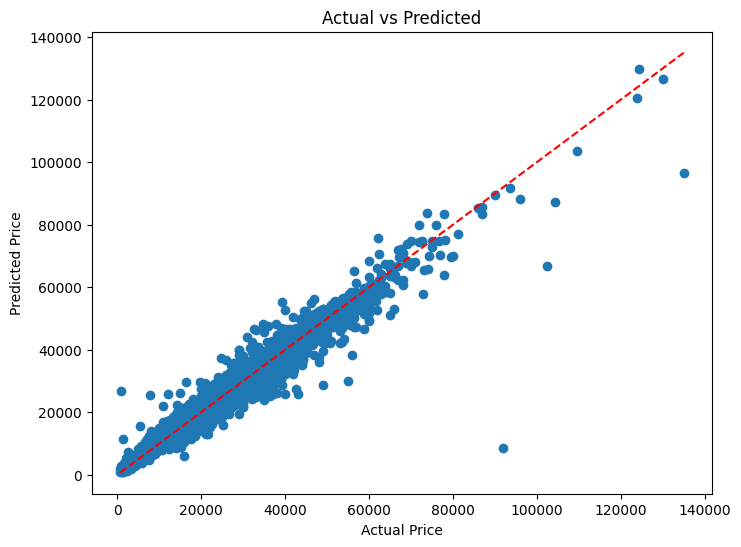

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

# :- Residual Plot

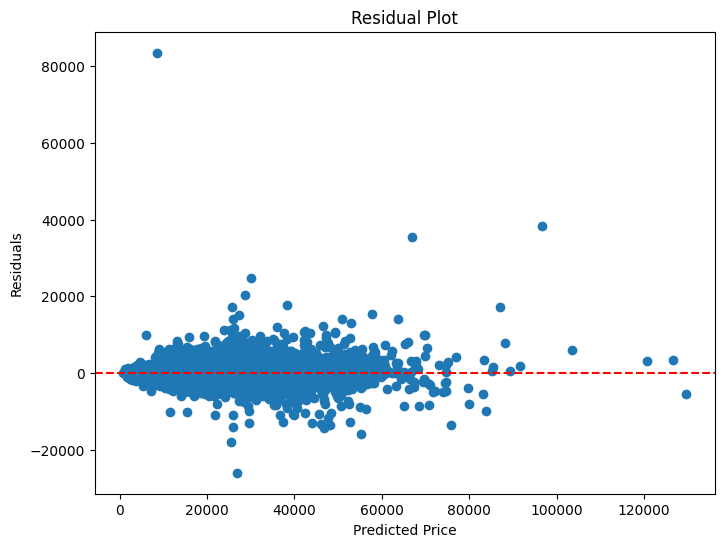

In [36]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# :- Distribution of Residuals

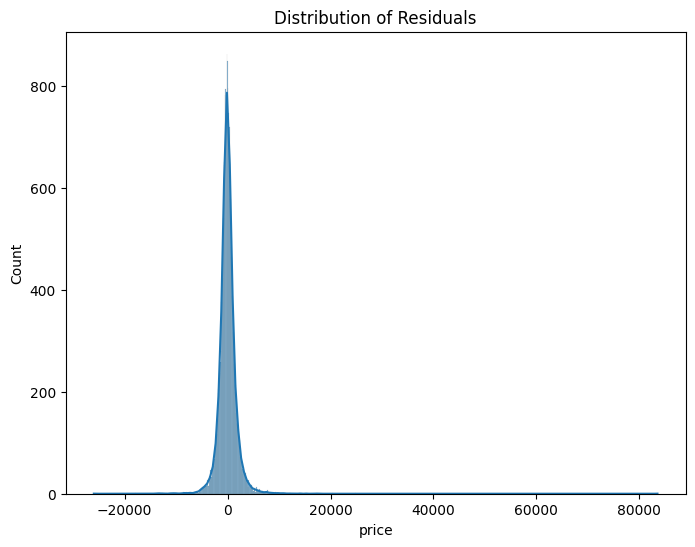

In [38]:
plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")

plt.show()

# :- Feature Importance

In [44]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(9)

,Feature,Importance
7,engineSize,0.521647
1,year,0.178044
4,fuelType,0.068745
3,mileage,0.053641
8,Make,0.052343
2,transmission,0.050096
6,mpg,0.034529
0,model,0.029116
5,tax,0.011839


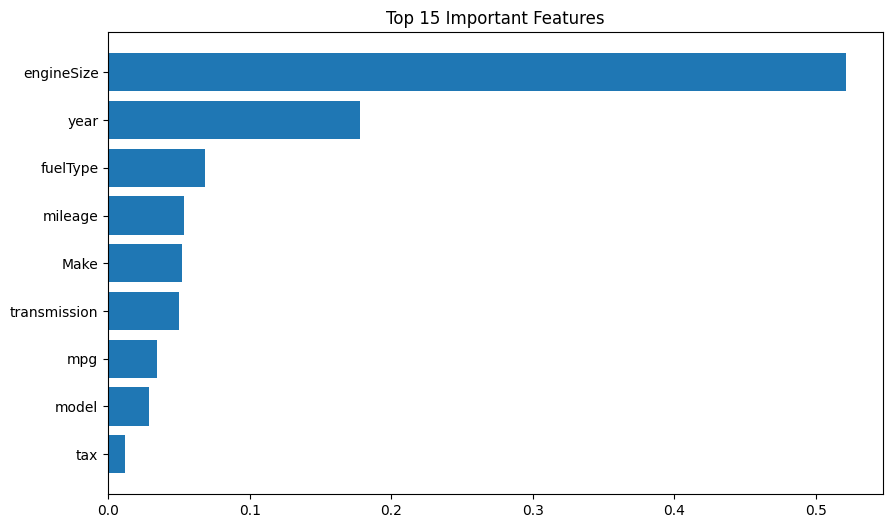

In [45]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

# Model Saving

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import joblib

In [47]:
categorical_features = [
    'model',
    'transmission',
    'fuelType',
    'Make'
]

numerical_features = [
    'year',
    'mileage',
    'tax',
    'mpg',
    'engineSize'
]

In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [49]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

In [50]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
joblib.dump(
    pipeline,
    "car_price_prediction_pipeline.pkl"
)

['car_price_prediction_pipeline.pkl']